## NYC Open Data - Exploratory Data Analysis
### CSE 6242 Group 173 -- Fall 2025

This notebook contains code for an exploratory data analysis (EDA) of NYC Open Data's [311 Service Requests from 2010 to Present](https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2010-to-Present/erm2-nwe9/about_data) dataset.

The timeframe considered in this EDA is as follows: 1/1/2014 to 12/31/2024 (inclusive). 

**VERSIONING** -- The snapshot of data considered here was obtained on: **10/22/2025**

## 0.0 Environment Setup

In [1]:
#environment setup - running list
import requests
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import colormaps
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
import textwrap
import squarify 
import json
#ADD BELOW AS NEEDED
from matplotlib.colors import LinearSegmentedColormap

## 1.0 Importing Data

### 1.1 Exploring NYC Open Data's API - Socrata Open Data (SODA) calls to pull data from the Web -- NOT RECOMMENDED
The following code provides an example of pulling NYC Open Data from the web via their SODA API. Note that parameters can be specified to query out larger datasets. From the Open Data portal itself, URL's including query logic can be exported as API endpoints as well. 

**Important Note:** Given the size of the 311 dataset (millions of rows > 3.5 gb in file size), this method is not optimized for a single, local machine. Therefore, it is not recommended to apply this approach without additional setup for processing performance.

In [ ]:
#NYC Open Data API is SODA - Socrata Open Data 
#using the .json extension is easiest
api_url = "https://data.cityofnewyork.us/resource/erm2-nwe9.json" #ENDPOINT for 311 data

#per documentation you can use query parameters in API call
#the 311 dataset is very large, over 5 million rows
#you can add other filters, such as for date or complaint_type
params = {
    #"$limit": 1000000, #pull first MILLION rows
    "$where": "contains(upper(complaint_type), 'NOISE') AND date_extract_y(created_date) IN (2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024)"
}

#ALT METHOD - query export URL
#URL extracted with query parameters
#'https://data.cityofnewyork.us/api/v3/views/erm2-nwe9/query.csv?query=SELECT%0A%20%20%60unique_key%60%2C%0A%20%20%60created_date%60%2C%0A%20%20%60closed_date%60%2C%0A%20%20%60agency%60%2C%0A%20%20%60agency_name%60%2C%0A%20%20%60complaint_type%60%2C%0A%20%20%60descriptor%60%2C%0A%20%20%60location_type%60%2C%0A%20%20%60incident_zip%60%2C%0A%20%20%60incident_address%60%2C%0A%20%20%60street_name%60%2C%0A%20%20%60cross_street_1%60%2C%0A%20%20%60cross_street_2%60%2C%0A%20%20%60intersection_street_1%60%2C%0A%20%20%60intersection_street_2%60%2C%0A%20%20%60address_type%60%2C%0A%20%20%60city%60%2C%0A%20%20%60landmark%60%2C%0A%20%20%60facility_type%60%2C%0A%20%20%60status%60%2C%0A%20%20%60due_date%60%2C%0A%20%20%60resolution_description%60%2C%0A%20%20%60resolution_action_updated_date%60%2C%0A%20%20%60community_board%60%2C%0A%20%20%60bbl%60%2C%0A%20%20%60borough%60%2C%0A%20%20%60x_coordinate_state_plane%60%2C%0A%20%20%60y_coordinate_state_plane%60%2C%0A%20%20%60open_data_channel_type%60%2C%0A%20%20%60park_facility_name%60%2C%0A%20%20%60park_borough%60%2C%0A%20%20%60vehicle_type%60%2C%0A%20%20%60taxi_company_borough%60%2C%0A%20%20%60taxi_pick_up_location%60%2C%0A%20%20%60bridge_highway_name%60%2C%0A%20%20%60bridge_highway_direction%60%2C%0A%20%20%60road_ramp%60%2C%0A%20%20%60bridge_highway_segment%60%2C%0A%20%20%60latitude%60%2C%0A%20%20%60longitude%60%2C%0A%20%20%60location%60%0AWHERE%0A%20%20%60created_date%60%0A%20%20%20%20BETWEEN%20%222014-12-31T23%3A45%3A00%22%20%3A%3A%20floating_timestamp%0A%20%20%20%20AND%20%222024-12-31T23%3A45%3A00%22%20%3A%3A%20floating_timestamp%0A%20%20AND%20caseless_contains(%60complaint_type%60%2C%20%22NOISE%22)%0AORDER%20BY%20%60created_date%60%20DESC%20NULL%20FIRST'

### 1.2 Attempting to store locally after SODA API call. -- NOT RECOMMENDED

This code retrieves NYC 311 noise complaint records from the Socrata Open Data API in batches of 50,000 to handle large datasets. It loops through the API using an offset until no more records are returned, appending each batch of results to a list. Finally, it converts all collected records into a pandas DataFrame for further analysis.

**Note:** This method is depreciated as appending time is lengthy for large datasets.

In [28]:
# #VERSION 2 -- initialize an object, pull from API, and append to object

# all_records = []
# offset = 0
# limit = 500000  # Max per request
# #NYC Open Data API is SODA - Socrata Open Data 
# #using the .json extension is easiest
# api_url = "https://data.cityofnewyork.us/resource/erm2-nwe9.json" #ENDPOINT for 311 data

# #LOOP 
#     #batch calls to API and obtain records
#     #append records to object 
# while True:
#      params = {
#          "$limit": limit,
#          "$offset": offset,
#          "$where": "contains(upper(complaint_type), 'NOISE') AND date_extract_y(created_date) IN (2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024)"
#      }
    
#      response = requests.get(api_url, params=params)
#      data = response.json()
    
#      if len(data) == 0:
#          break
    
#      all_records.extend(data)
#      offset += limit
#      print(f"Fetched {len(all_records)} records so far...")

# df = pd.DataFrame(all_records)

### 1.3 Trying Error-handling batches to flag issues. -- NOT RECOMMENDED

This code makes a single API request to the NYC 311 endpoint using specified parameters and handles any potential HTTP or general errors with a try-except block. If successful, it converts the JSON response into a pandas DataFrame and prints a summary including the number of records, dataset dimensions, the first five rows, and DataFrame info. The error handling ensures that issues during the request are caught and reported clearly.

**Note:** Depreciated due to processing time of large datasets identified above. 

In [ ]:
# #making the API request
# #use params specified above
# #wrapped in a try-except block for error detection 
# try:
#     response = requests.get(api_url, params=params)
#     #will raise an HTTPError if the HTTP request returned an unsuccessful status code
#     response.raise_for_status()

#     #load result data into a pandas df object
#     #the JSON response can be directly placed in a df 
#     data = response.json()
#     df_noise = pd.DataFrame(data)
    
#     print(f"Successfully fetched {len(df_noise)} records from the NYC 311 API.")
    
#     #DATA PREVIEW 
#     print("\nDimensions of the dataset:")
#     print(df_noise.shape)
#     #first 5 rows of the dataset
#     print("\nFirst 5 rows of the dataset:")
#     print(df_noise.head())

#     #summary of the df
#     print("\nDataFrame Info:")
#     df_noise.info()

# #except requests.exceptions.HTTPError as http_err:
#     print(f"HTTP error occurred: {http_err}")
# #except Exception as err:
#     print(f"An error occurred: {err}")

### 1.4 Import 311 Data directly from NYC Open Data Download (csv). -- RECOMMENDED

**Note:** Subsequent code in this notebook assumes that this import procedure has been followed as shown below. 

In [29]:
#read in the CSV file
df_noise = pd.read_csv('311_Service_Requests_Combined.csv')

#dataset preview -- display basic info
print(df_noise.head())        #top 5 rows
print(df_noise.shape)         #gives (rows, columns)
print(df_noise.columns)       #column names
print(df_noise.info())        #review data types and non-null counts

/var/folders/6_/y7s2l4ps5_5b8t_y0rl5p0500000gn/T/ipykernel_56589/97232956.py:2: DtypeWarning: Columns (17,18,20,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df_noise = pd.read_csv('311_Service_Requests_Combined.csv')


   Unique Key            Created Date             Closed Date Agency  \
0    63579931  12/31/2024 11:44:57 PM  01/02/2025 05:05:54 PM   NYPD   
1    63577924  12/31/2024 11:44:57 PM  01/01/2025 09:01:31 AM   NYPD   
2    63578057  12/31/2024 11:44:53 PM  01/02/2025 05:08:19 PM   NYPD   
3    63581018  12/31/2024 11:44:51 PM  12/31/2024 11:47:30 PM   NYPD   
4    63582376  12/31/2024 11:44:43 PM  12/31/2024 11:58:52 PM   NYPD   

                       Agency Name       Complaint Type        Descriptor  \
0  New York City Police Department  Noise - Residential  Loud Music/Party   
1  New York City Police Department  Noise - Residential  Loud Music/Party   
2  New York City Police Department  Noise - Residential  Loud Music/Party   
3  New York City Police Department  Noise - Residential  Loud Music/Party   
4  New York City Police Department   Noise - Commercial  Loud Music/Party   

                Location Type  Incident Zip        Incident Address  ...  \
0  Residential Building/Hous

## 2.0 Exploratory Data Analysis of 311 Dataset
The following code portions perform the EDA of data imported following (1.4) above. Many of the variables in the raw data are descriptive in nature, geographic, or time-based objects. This analysis considers those broad categorizations of the variables throughout exploration.

#### Simple Data Exploration -- Unique Values per Column
This code analyzes any specified column in a DataFrame by counting the occurrences of each unique value. It converts the resulting Series of value counts into a DataFrame with columns description and count for easy viewing. If the column doesn’t exist in the DataFrame, it prints an error message instead of failing.

In [30]:
#replace with. column name of interest
column_to_analyze = 'Resolution Description'

print(f"Finding unique values in column: '{column_to_analyze}'")
print("-------------------------------------------------")

#loop for value counts 
if column_to_analyze in df_noise.columns:
    value_counts_series = df_noise[column_to_analyze].value_counts()
    # .reset_index() turns the Series index (the unique values) into a column
    counts_df = value_counts_series.reset_index()
    #rename the columns to 'description' and 'count'
    counts_df.columns = ['description', 'count']
    print(f"\nFound {len(counts_df)} unique values:")
    print("------------------------------------")
    print(counts_df)
else:
    print(f"Error: Column '{column_to_analyze}' was not found in the DataFrame.")


Finding unique values in column: 'Resolution Description'
-------------------------------------------------

Found 85 unique values:
------------------------------------
                                          description    count
0   The Police Department responded to the complai...  2251488
1   The Police Department responded to the complai...  1809404
2   The Police Department responded to the complai...   680155
3   The Department of Environmental Protection (DE...   326407
4   The Police Department responded to the complai...   205827
..                                                ...      ...
80  The Department of Environmental Protection inv...        1
81  This Service Request is not within the Departm...        1
82  The Department of Environmental Protection sen...        1
83      The Department of Sanitation plowed the area.        1
84  Your complaint has been submitted to the New Y...        1

[85 rows x 2 columns]


#### Configure -- Generalized EDA Helper Function -- get_value_counts_df()
This code defines a helper function **get_value_counts_df** that takes a DataFrame and a column name, returning a new DataFrame with each unique value and its count. It checks if the column exists, prints an error if not, and otherwise formats the counts into description and count columns. The example usage applies it to the Agency column in df_noise and prints the resulting summary DataFrame.

In [31]:
#helper function to get summary quick 
def get_value_counts_df(df: pd.DataFrame, column_name: str) -> pd.DataFrame:
    if column_name not in df.columns:
        print(f"Error: Column '{column_name}' not found in the DataFrame.")
        return None
    value_counts_series = df[column_name].value_counts()
    counts_df = value_counts_series.reset_index()
    counts_df.columns = ['description', 'count']
    return counts_df

#EXAMPLE 
target_df = df_noise
target_column = 'Agency' 

print(f"Getting value counts for column: '{target_column}'")
counts_as_df = get_value_counts_df(df=target_df, column_name=target_column)

#display result
if counts_as_df is not None:
    print("\n--- Result ---")
    print(counts_as_df)

Getting value counts for column: 'Agency'

--- Result ---
  description    count
0        NYPD  5509128
1         DEP   589887
2         EDC   159546
3        DSNY     1681
4       DOITT        3
5       3-1-1        2
6         DPR        1


#### Configure -- Data Viz Custom Palettes
This code defines a custom neon-inspired color palette representing varying noise levels, from loud reds for sirens and construction to dark grays for silence. It then creates a continuous colormap (neon_cmap) from this list using LinearSegmentedColormap.from_list, which can be applied to visualizations for consistent, visually intuitive coloring. This setup allows subsequent plots to use the neon gradient to reflect noise intensity or data magnitude.

In [5]:
#Define a custom neon color palette -- use for following data viz outputs 
neon_colors = [
    '#8B0000',  # Dark red
    '#FF0000',  # Loud red (sirens, alarms)
    '#FF4500',  # Orange red (construction)
    '#FF6347',  # Tomato (street noise)
    '#FF8C00',  # Dark orange (traffic)
    '#FFA500',  # Orange (horns)
    '#FFD700',  # Gold (transition)
    '#87CEEB',  # Sky blue (quieter)
    '#4682B4',  # Steel blue (calm)
    '#5F9EA0',  # Cadet blue (peaceful)
    '#708090',  # Slate gray (quiet)
    '#2F4F4F'   # Dark slate gray (silence)
]

#define some distinct color palettes from the neon colors
#warm reds/oranges
complaint_colors = [
    '#FF0000',  
    '#FF4500',  
    '#FF6347',  
    '#FF8C00',  
    '#FFA500',  
    '#FFD700',  
]

#transition gold/yellows
agency_colors = [
    '#FFD700',
    '#FFA500',  
    '#FF8C00',  
    '#DAA520',  
    '#B8860B',  
    '#CD853F',  
]

#cool blues/grays
borough_color_map = {
    'MN': '#87CEEB',
    'BK': '#4682B4', 
    'QN': '#5F9EA0',  
    'BX': '#708090',  
    'SI': '#2F4F4F',  
    'Unspecified': '#A9A9A9' 
}

#create a custom colormap from neon_colors
neon_cmap = LinearSegmentedColormap.from_list('neon_noise', neon_colors)
complaint_cmap = LinearSegmentedColormap.from_list('complaint_palette', complaint_colors)
agency_cmap = LinearSegmentedColormap.from_list('agency_palette', agency_colors)


#### Setup -- Copy Data

In [6]:
#calculate the frequency of blank values per column
#create a temporary copy to work with below 
df_copy = df_noise.copy()

### 2.1 Examination of Variable Completeness & Data Gaps
This portion of the EDA is an assessment of recordset completion. All columns present in the 311 dataset were considered here. The count of [null] or 0 values, respectively, were used to estimate a proportion of 'missingness' with respect to the overall dataset. 

### Pre-requisite -- String Data Cleaning & Processing 
This code standardizes all “blank” text values in a DataFrame by replacing empty strings or strings with only whitespace with NaN. It then counts the number of nulls in each column and identifies which columns have no missing values. Optionally, it can filter the counts to focus only on columns that actually contain blanks.

In [7]:
#replace empty strings or strings with only whitespace with NaN
#this standardizes all "blank" text values
for col in df_copy.select_dtypes(include=['object']).columns:
    #use .str.strip() to remove leading/trailing whitespace
    #it becomes an empty string ''. 
    #replace the empty string with NaN and assign it back to the column - avoid copy warning 
    df_copy[col] = df_copy[col].str.strip().replace('', np.nan)

#now that all types of blanks are represented as NaN, we can get a count of nulls
blank_counts = df_copy.isnull().sum()

#get columns that don't have any NaNs
cols_without_nans = blank_counts[blank_counts == 0].index.tolist()
print(f"Columns without NaNs ({len(cols_without_nans)}): {cols_without_nans}")

#OPTIONAL - filter the series to only include columns that actually have blank values.
#makes the chart cleaner and more focused.
#blank_counts = blank_counts[blank_counts > 0]

Columns without NaNs (8): ['Unique Key', 'Created Date', 'Agency', 'Agency Name', 'Complaint Type', 'Status', 'Open Data Channel Type', 'Park Facility Name']


### Data Viz -- Proportions of Missing Values

This code creates a customized bar chart showing the number of blank values per column in a DataFrame. It sorts the counts in descending order, applies a custom colormap, labels each bar with the percentage of total blanks, and adjusts figure size, axis labels, and layout for readability. If no blanks exist, it simply prints a congratulatory message instead of generating a plot.

**Note:** Variables shown in the following plot are only those with at least 1 missing value. Variables that have no missing values are excluded from the plot. 

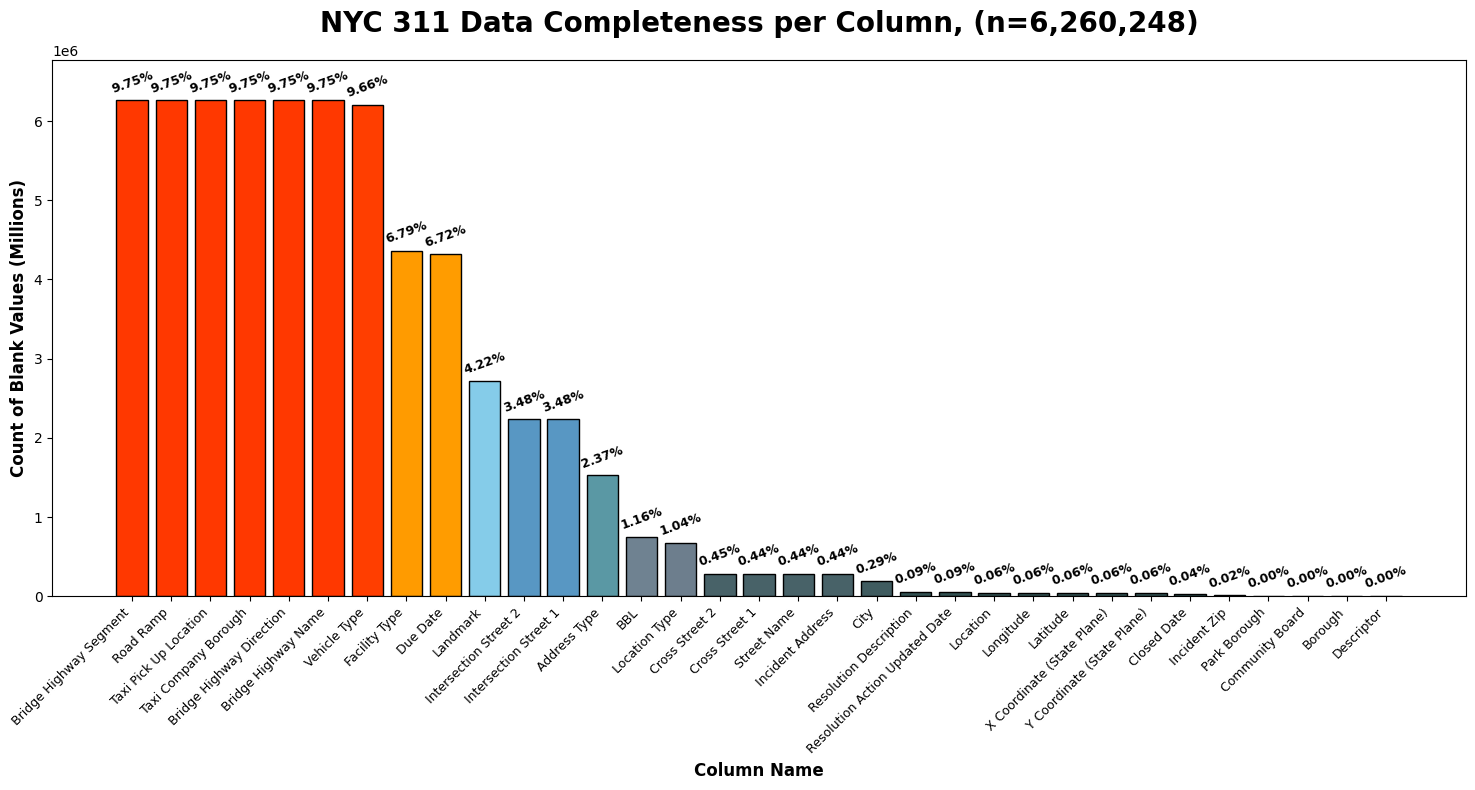

In [8]:
#sort counts in descending order for visualization
blank_counts.sort_values(ascending=False, inplace=True)
blank_counts = blank_counts[blank_counts > 0]

#create a sorted bar chart with customization
if not blank_counts.empty:
    #normalize to map data values to the 0-1 range for the colormap
    norm = colors.Normalize(vmin=blank_counts.min() * 0.8, vmax=blank_counts.max() * 1.2)

    #set a figure size - change for specific layout
    plt.figure(figsize=(15, 8))

    #create a bar chart with custom styling 
    bars = plt.bar(
        blank_counts.index, #x axis
        blank_counts.values, #y axis
        color=neon_cmap.reversed()(norm(blank_counts.values)),  #apply the custom neon colormap - invert for high to low
        edgecolor='black',
        width=0.8  #increase space between bars
    )

    #add titles and labels 
    plt.title(f'NYC 311 Data Completeness per Column, (n={len(df_noise):,})', fontsize=20, fontweight='bold', pad=20)
    plt.ylabel('Count of Blank Values (Millions)', fontsize=12, fontweight='bold')
    plt.xlabel('Column Name', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right',fontsize=9)

    #calculate total sum for percentages
    total_count = blank_counts.sum()
    #add percentage on top of each bar as a label 
    for bar in bars:
        yval = bar.get_height()
        #calc percentage -- IMPORTANT MUST HANDLE -- division by zero
        percent = (yval / total_count) * 100 if total_count > 0 else 0
        #add vertical offset to prevent numbers from touching the bar
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + blank_counts.max()*0.01, f'{percent:.2f}%',
                 ha='center', va='bottom', fontweight='bold', fontsize=9, rotation=20)

    #format layout
    plt.tight_layout()
    #get y-axis limit and add padding
    _, y_max = plt.ylim()
    plt.ylim(top=y_max + 200000)
    #show the final plot
    plt.show()

#in case there is no missing data
else:
    print("Congratulations! No blank values were found in ANY columns!")

### 2.2 Exploring Categorical Variables -- 'Complaint Type' , 'Community Board', 'Agency', & 'Borough'
This code selects specific columns of interest (Complaint Type, Community Board, and Agency) from the DataFrame for analysis. It initializes an empty dictionary to later store the value counts for each of these columns. Additionally, it defines a mapping from full NYC borough names to their standard two-letter abbreviations for easier reference in analyses or visualizations.

In [9]:
#get column names of interest to us
#df_noise.columns
columns_to_plot = ['Complaint Type', 'Community Board', 'Agency']

#initialize an empty dict to store value counts per variable of interest 
value_counts_dict = {}

#dictionary to map full borough names to their abbreviation
borough_name_map = {
    'MANHATTAN': 'MN',
    'QUEENS': 'QN',
    'BROOKLYN': 'BK',
    'BRONX': 'BX',
    'STATEN ISLAND': 'SI'
}

### Data Processing -- Community Board & Complaint Type Codes
This code loops through the selected columns (Complaint Type, Community Board, Agency) and calculates the value counts for each. For Community Board, it abbreviates borough names, separates parsable and non-parsable entries, and sorts the parsable entries by borough and board number before combining them. For Complaint Type, it removes the "Noise - " prefix, and all processed counts are stored in a dictionary for later use.

In [10]:
#loop through columns above and process 
for column_name in columns_to_plot:
    counts = df_noise[column_name].value_counts()
    
    if column_name == 'Community Board':
        #abbreviate the index labels
        new_index = counts.index
        for full_name, abbr in borough_name_map.items():
            new_index = new_index.str.replace(full_name, abbr)
        counts.index = new_index
        
        #use a TEMP df to apply sorting logic 
        df_temp = pd.DataFrame({'counts': counts})
        #use errors='coerce' to turn non-numeric board numbers into 'NaN'
        df_temp['board_num'] = pd.to_numeric(df_temp.index.str.split().str[0], errors='coerce')
        df_temp['borough'] = df_temp.index.str.split().str[-1]
        #separate data into parsable (good) and non-parsable (bad)
        df_good = df_temp[df_temp['board_num'].notna()].copy()
        df_bad = df_temp[df_temp['board_num'].isna()].copy()
        #sort the good data by borough and board number
        df_good['board_num'] = df_good['board_num'].astype(int)
        df_good_sorted = df_good.sort_values(['borough', 'board_num'])
        #combine the sorted good data with the bad data at the end
        df_final_sorted = pd.concat([df_good_sorted, df_bad])
        #recreate the 'counts' Series in the new, correct order
        counts = df_final_sorted['counts']

    elif column_name == 'Complaint Type':
        #remove the "Noise - " prefix
        counts.index = counts.index.str.replace('Noise - ', '', regex=False)
    #finalize
    value_counts_dict[column_name] = counts

print("Value counts have been calculated and processed with sorting.")
#print("\n--- Example of 'community_board' data (unspecified values will be at the end) ---")
#print(value_counts_dict['community_board'])


Value counts have been calculated and processed with sorting.


### Data Viz -- Noise Complaint Type, Responding Agency, & Community Boards
This code visualizes value counts for **Complaint Type, Agency, and Community Board** using bar charts. It assigns custom colors to each category based on predefined palettes or borough abbreviations. The charts are displayed together in a multi-plot layout. Labels, titles, and tick formatting are adjusted for readability.

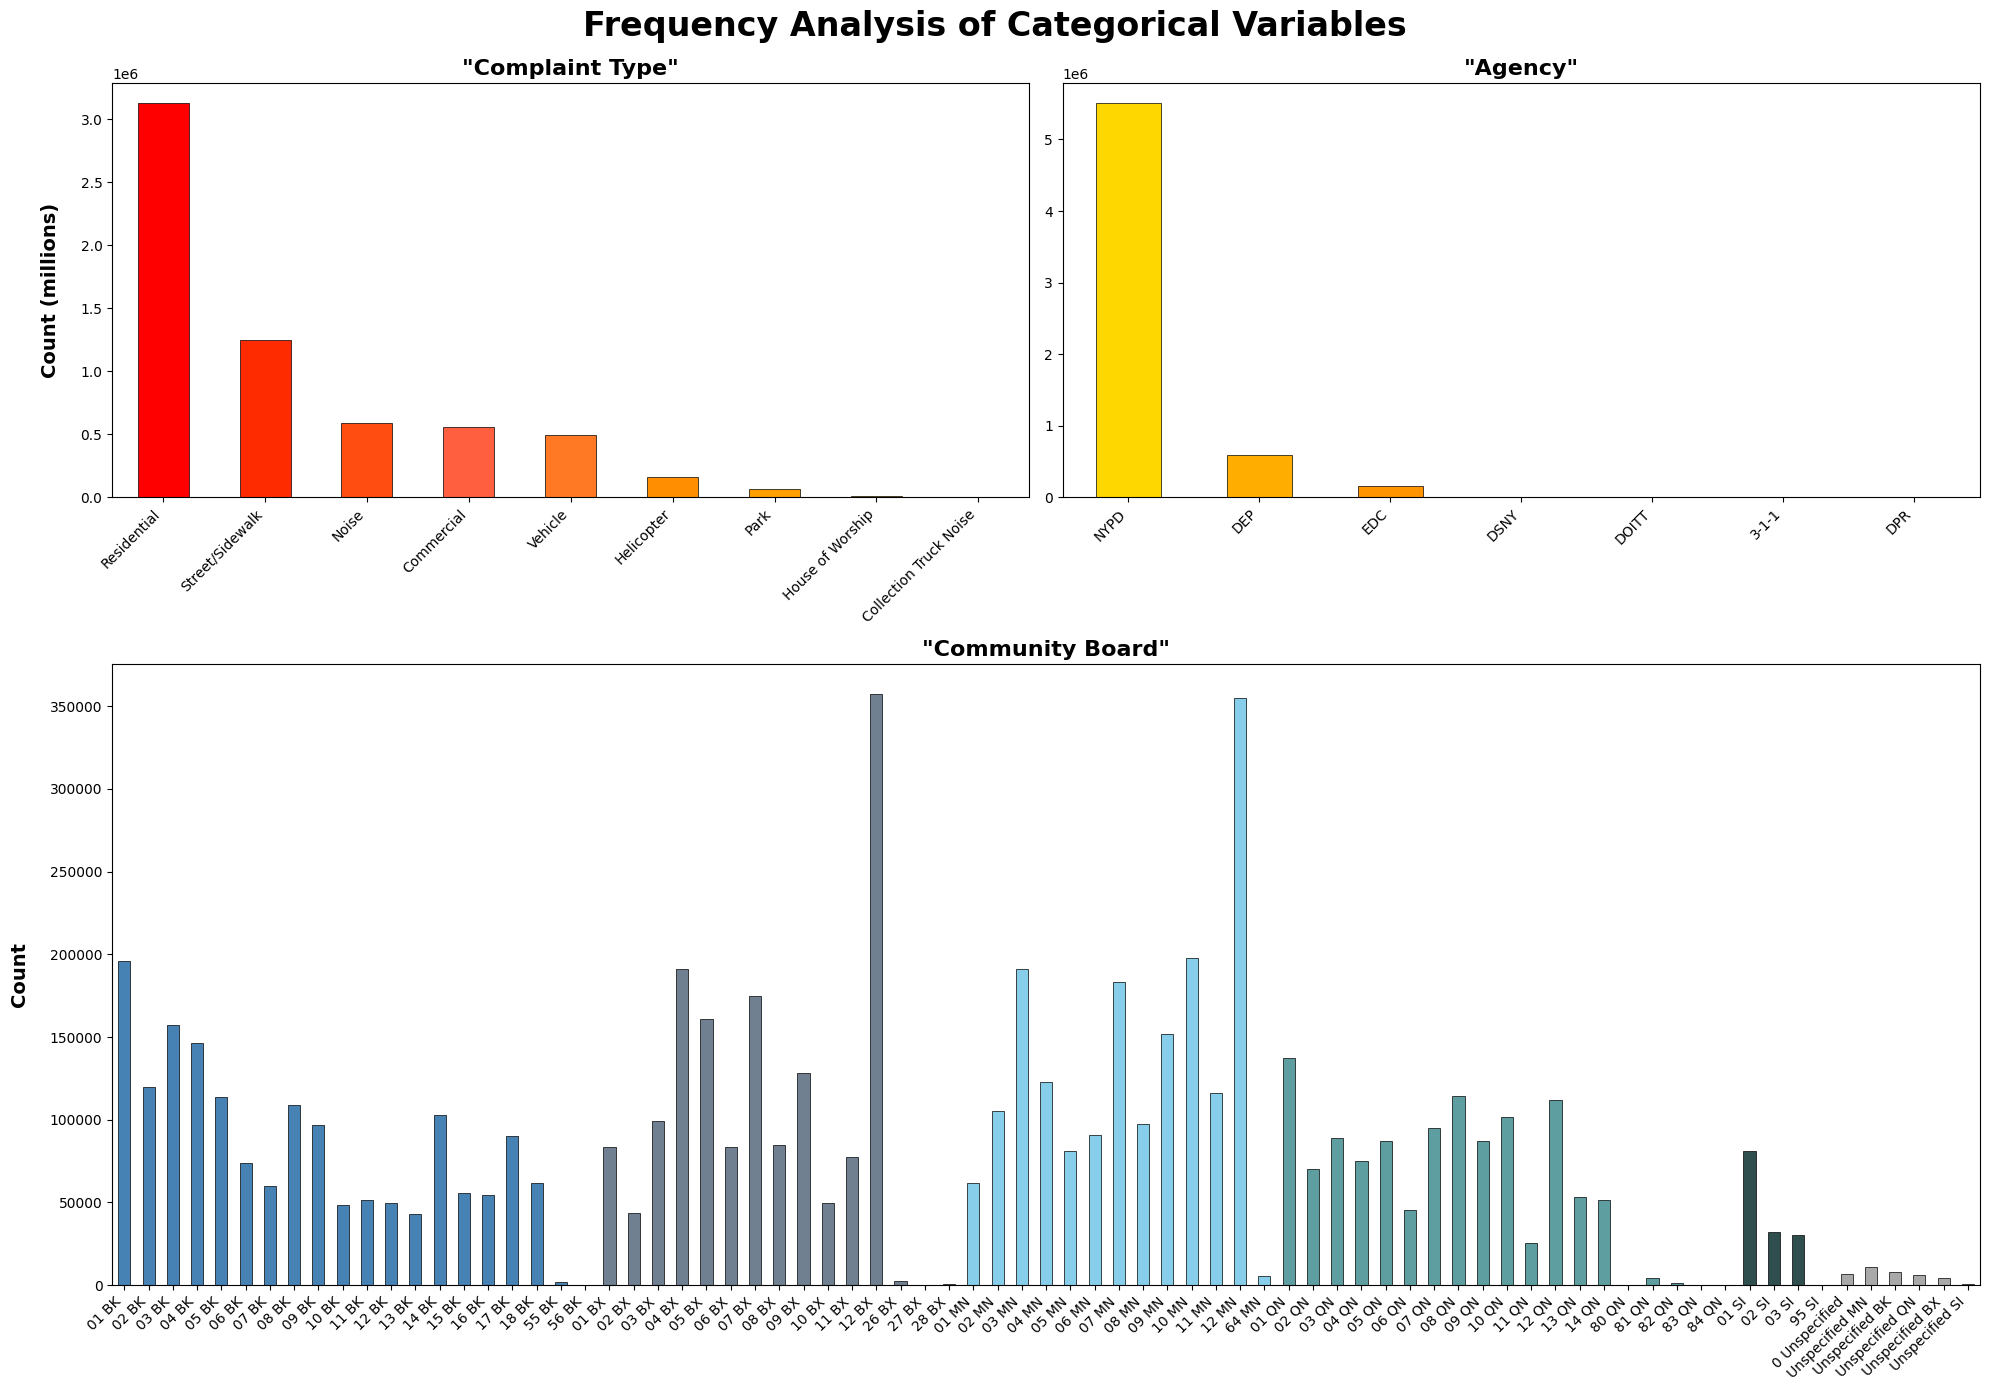

In [11]:
#specify columns that will be plotted
columns_for_new_layout = ['Complaint Type', 'Agency', 'Community Board']

#create a figure to hold the plots - adjust for layout size
fig = plt.figure(figsize=(20, 14))

#add overall main title
fig.suptitle('Frequency Analysis of Categorical Variables', fontsize=24, fontweight='bold', y=0.99)

#create a 2-row, 2-column grid specification with adjusted heights
gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[0.8, 1.2])

#create the subplots in their desired grid positions
#TOP ROW
ax1 = fig.add_subplot(gs[0, 0])  #LEFT cell of the first row
ax2 = fig.add_subplot(gs[0, 1])  #RIGHT cell of the first row
#BOTTOM ROW (spanning both columns)
ax3 = fig.add_subplot(gs[1, :])  #BOTH cells of the second row
#group the axes into a list for easy iteration
axes_list = [ax1, ax2, ax3]

#LOOP -- through the chosen columns and the axes to create the plots
for i, column_name in enumerate(columns_for_new_layout):
    #get the pre-calculated counts from the dictionary
    counts = value_counts_dict[column_name]
    #select the current axis
    current_ax = axes_list[i]
    
    #generate colors based on plot type
    if column_name == 'Community Board':
        #apply borough colormap
        bar_colors = []
        for label in counts.index:
            if 'Unspecified' in label:
                bar_colors.append(borough_color_map['Unspecified'])
            else:
                #extract borough abbreviation (last part after space)
                borough_abbr = label.split()[-1]
                bar_colors.append(borough_color_map.get(borough_abbr, '#808080'))
    elif column_name == 'Complaint Type':
        #apply complaint colormap
        norm = colors.Normalize(vmin=0, vmax=len(counts)-1)
        bar_colors = [complaint_cmap(norm(j)) for j in range(len(counts))]
    elif column_name == 'Agency':
        #apply agency colormap
        norm = colors.Normalize(vmin=0, vmax=len(counts)-1)
        bar_colors = [agency_cmap(norm(j)) for j in range(len(counts))]

    #plot data with black edgecolor
    counts.plot(kind='bar', ax=current_ax, rot=45, color=bar_colors, edgecolor='black', linewidth=0.5)
    
    #format titles and labels
    current_ax.set_title(f'"{column_name}"', fontsize=16, fontweight='bold')
    current_ax.set_xlabel('')
    
    #add ylabel for upper left (i=0) and bottom (i=2) plots
    if i == 0:
        current_ax.set_ylabel('Count (millions)', fontweight='bold', fontsize=14, labelpad=15)
    elif i == 2:
        current_ax.set_ylabel('Count', fontweight='bold', fontsize=14, labelpad=15)
    
    #set font size for the x-axis tick labels
    current_ax.tick_params(axis='x', labelsize=10)
    #adjust horizontal alignment ('ha') of the rotated labels to 'right'
    #anchor right side of the label text to ticks
    plt.setp(current_ax.get_xticklabels(), ha='right')

#adjust layout and display result
plt.tight_layout()
plt.show()

### 2.3 Exploring Categorical Variables -- Noise Complaint Type vs Borough
This code visualizes noise complaints by NYC borough in two bar charts. The first chart shows total complaint counts per borough with custom colors and value labels, while the second chart breaks down the complaints by type in a stacked bar format. Custom sorting, color mapping, and labels are applied to improve readability and highlight both overall and category-specific trends.

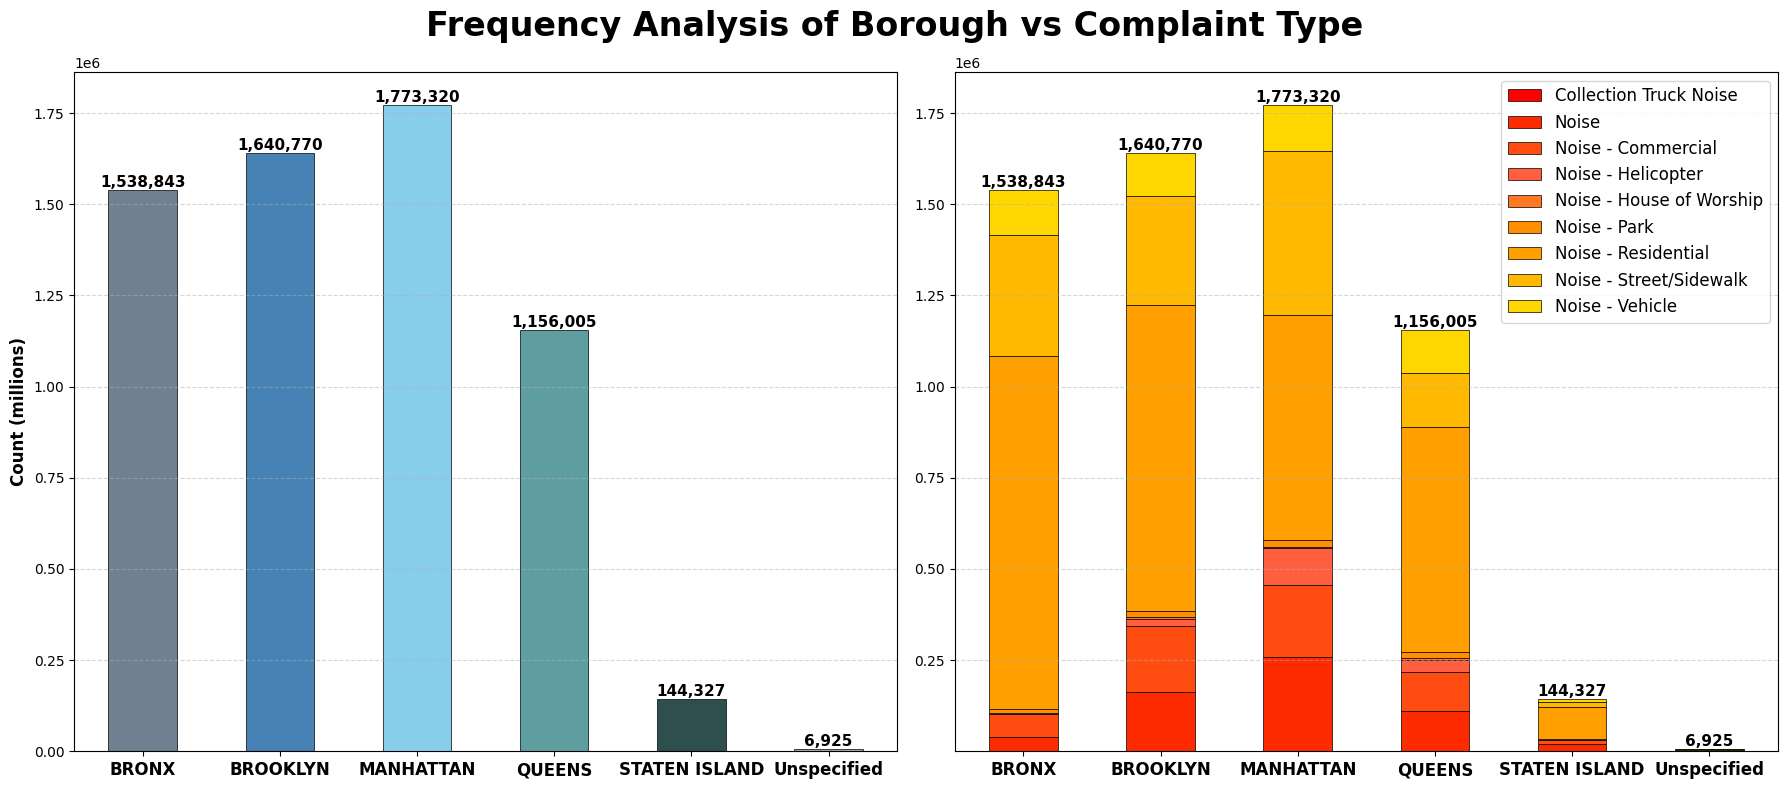

In [12]:
#mapping function from full names to abbreviations
borough_abbr_map = {
    'MANHATTAN': 'MN',
    'BROOKLYN': 'BK',
    'QUEENS': 'QN',
    'BRONX': 'BX',
    'STATEN ISLAND': 'SI',
    'Unspecified': 'Unspecified'
}

#get frequency values for borough counts
borough_counts = df_copy['Borough'].value_counts()

#define a custom sort order: alphabetical + Unspecified at end
borough_order = ['BRONX', 'BROOKLYN', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND', 'Unspecified']
borough_order = [b for b in borough_order if b in borough_counts.index]

#re-index borough counts to follow the custom order
borough_counts = borough_counts.reindex(borough_order)

#map colors to the actual borough values in data
bar_colors = [borough_color_map.get(borough_abbr_map.get(borough, borough), 'grey') for borough in borough_counts.index]

#crosstab of Borough vs Complaint Type and reindex
borough_complaint = pd.crosstab(df_copy['Borough'], df_copy['Complaint Type'])
borough_complaint = borough_complaint.reindex(borough_order)

#generate complaint type colors from complaint_cmap
norm = colors.Normalize(vmin=0, vmax=len(borough_complaint.columns)-1)
complaint_hex = [complaint_cmap(norm(i)) for i in range(len(borough_complaint.columns))]

#create figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

#add main title
fig.suptitle('Frequency Analysis of Borough vs Complaint Type', fontsize=24, fontweight='bold', y=0.98)

#first graph -- simple borough counts
borough_counts.plot(kind='bar', ax=ax1, rot=0, color=bar_colors, edgecolor='black', linewidth=0.5)

ax1.set_title('')
ax1.set_xlabel('')
ax1.set_ylabel('Count (millions)', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', labelsize=12)
plt.setp(ax1.get_xticklabels(), ha='center', fontweight='bold')

#add value labels on bars
for i, (count, patch) in enumerate(zip(borough_counts.values, ax1.patches)):
    height = patch.get_height()
    ax1.text(patch.get_x() + patch.get_width()/2., height,
            f'{int(count):,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.grid(axis='y', linestyle='--', alpha=0.5)

#second graph -- stacked bar by complaint types
borough_complaint.plot(kind='bar', stacked=True, ax=ax2, rot=0, 
                       color=complaint_hex,
                       edgecolor='black', linewidth=0.5)

ax2.set_title('')
ax2.set_xlabel('')
ax2.tick_params(axis='x', labelsize=12)
plt.setp(ax2.get_xticklabels(), ha='center', fontweight='bold')

#position legend in upper right corner
ax2.legend(title='', loc='upper right', fontsize=12)

ax2.grid(axis='y', linestyle='--', alpha=0.5)

#add total count labels on top of stacked bars
for i, (borough, total) in enumerate(borough_complaint.sum(axis=1).items()):
    ax2.text(i, total,
            f'{int(total):,}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### 2.4 Exploring Categorical Variables -- 'Facility Type', 'Resolution Description' & 'Location Type' 
This code creates a multi-panel visualization summarizing key aspects of the 311 noise complaint data. It shows the top 10 “Resolution Descriptions” as a lollipop chart, the distribution of “Status” values as a labeled horizontal bar chart, and the top 5 “Location Types” as a treemap. The three plots are arranged under a main title with a clean, balanced layout.

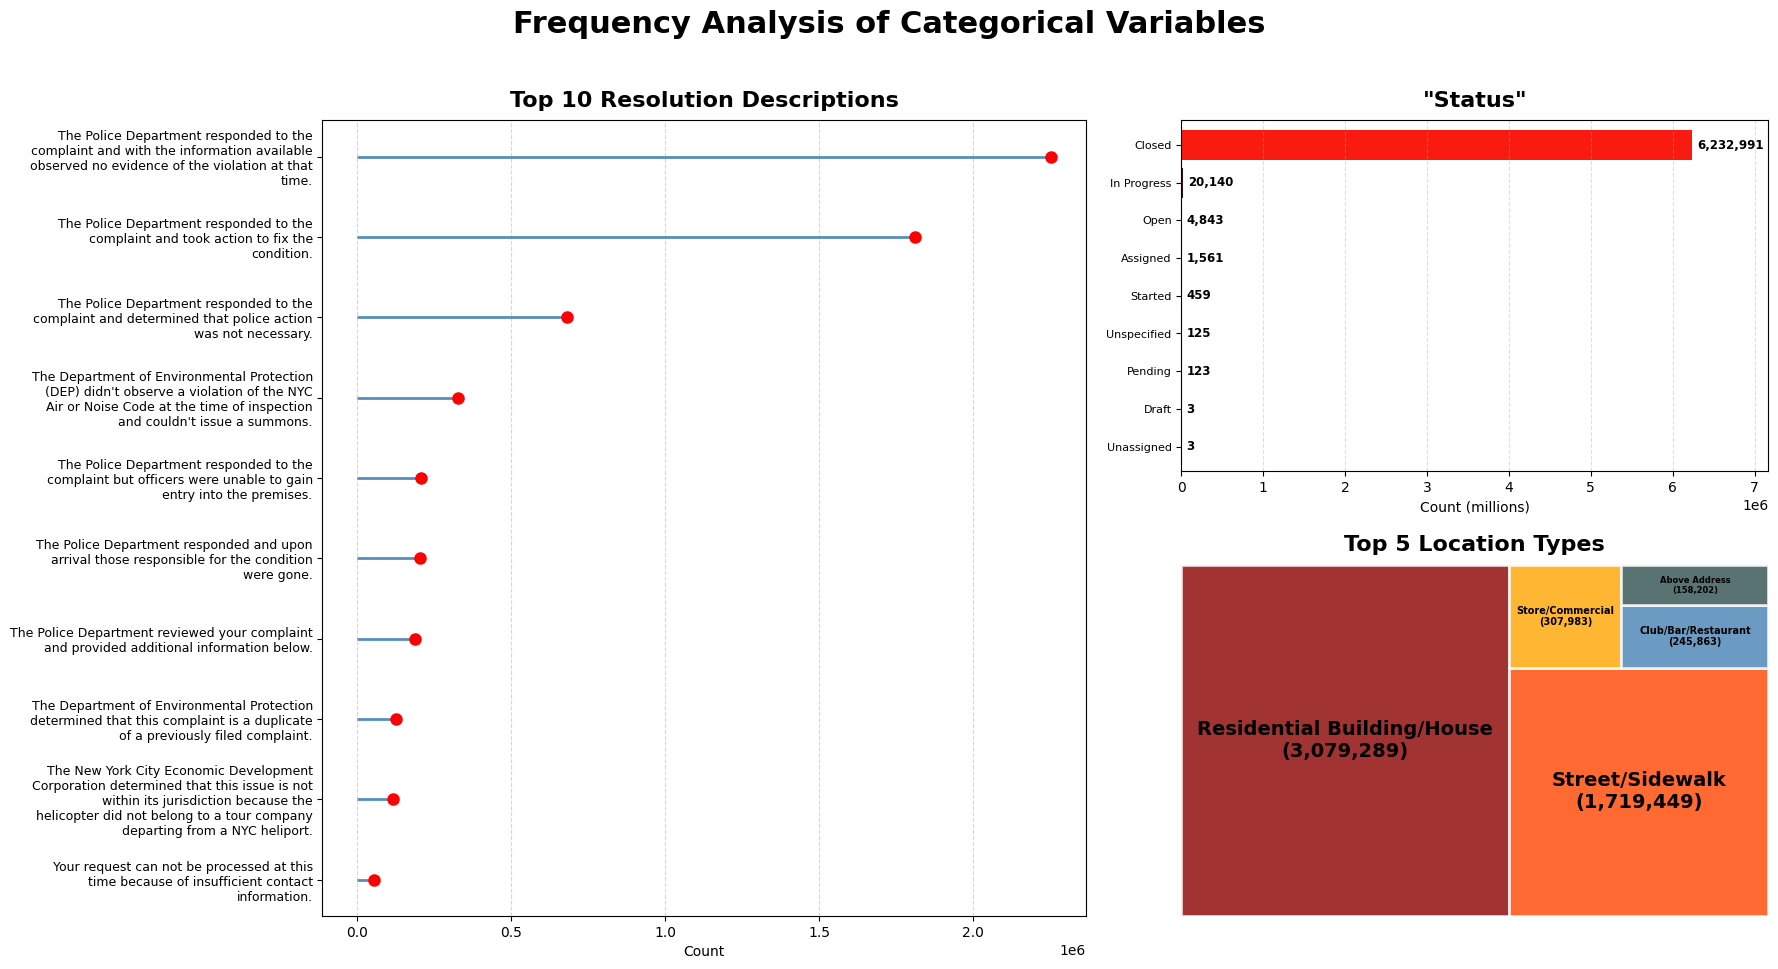

In [13]:
#DATA PREP
#Resolution Description (lollipop)
description_counts = df_noise['Resolution Description'].value_counts()
top_n = 10
plot_data_desc = description_counts.head(top_n).sort_values(ascending=True)

#311 status (bar)
status_counts = df_noise['Status'].value_counts()
plot_data_status = status_counts.sort_values(ascending=True)

#Location Type (treemap)
top_n_tree = 5
location_type_counts = df_noise['Location Type'].value_counts().head(top_n_tree)

#OVERALL FIGURE LAYOUT
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2, width_ratios=[1.3, 1], height_ratios=[1, 1])
ax1 = fig.add_subplot(gs[:, 0])   #Lollipop
ax2 = fig.add_subplot(gs[0, 1])   #Bar
ax3 = fig.add_subplot(gs[1, 1])   #Treemap

#MAIN TITLE
fig.suptitle("Frequency Analysis of Categorical Variables", fontsize=22, fontweight='bold', y=0.97)  #lower closer to subplots

#PLOT 1: Resolution Description (Lollipop)
ax1.hlines(range(len(plot_data_desc)), 0, plot_data_desc.values, color='#4682B4', alpha=0.9, linewidth=2)
ax1.plot(plot_data_desc.values, range(len(plot_data_desc)), "o", markersize=8, color='#FF0000')
ax1.set_yticks(range(len(plot_data_desc)))
wrapped_labels = [textwrap.fill(label.split('.')[0] + '.', width=45) for label in plot_data_desc.index]
ax1.set_yticklabels(wrapped_labels, fontsize=9)
ax1.set_title(f'Top {top_n} Resolution Descriptions', fontsize=16, fontweight='bold', pad=10)
ax1.set_xlabel('Count', fontsize=10)
ax1.grid(axis='x', linestyle='--', alpha=0.5)

#PLOT 2: Status (Horizontal Bar with labels)
hex_color_list = ['#3c0f0f', '#f91a10', '#e46b43', '#edb195', '#2aa7c9', '#06628d', '#04284d']
bars = plot_data_status.plot(kind='barh', ax=ax2, width=0.8, color=hex_color_list)
labels_bar = [textwrap.fill(label, width=40) for label in plot_data_status.index]
ax2.set_yticklabels(labels_bar, fontsize=8)
ax2.set_title('"Status"', fontsize=16, fontweight='bold', pad=10)
ax2.set_xlabel('Count (millions)', fontsize=10)
ax2.set_ylabel('')
ax2.grid(axis='x', linestyle='--', alpha=0.4)
#add labels to the end of bars (adjust xlim to fit)
x_max = max(plot_data_status.values)
for i, (value, name) in enumerate(zip(plot_data_status.values, plot_data_status.index)):
    ax2.text(value + x_max * 0.01, i, f"{value:,}",
             va='center', fontsize=8.5, color='black', fontweight='bold')
ax2.set_xlim(0, x_max * 1.15)  #extend x-axis so labels stay inside frame

#PLOT 3: Location Type (Treemap)
#evenly spaced colors from neon_colors
color_indices = np.linspace(0, len(neon_colors) - 1, top_n_tree).astype(int)
treemap_colors = [neon_colors[i] for i in color_indices]

#plot treemap cells and get rectangles
rects = squarify.normalize_sizes(location_type_counts.values, 100, 100)
rects = squarify.squarify(rects, 0, 0, 100, 100)

#draw rectangles manually with custom font sizes
for i, (rect, (label, count)) in enumerate(zip(rects, location_type_counts.items())):
    x, y, dx, dy = rect['x'], rect['y'], rect['dx'], rect['dy']
    
    #draw rectangle
    ax3.add_patch(plt.Rectangle((x, y), dx, dy, 
                                facecolor=treemap_colors[i], 
                                edgecolor='white', 
                                linewidth=2, 
                                alpha=0.8))
    
    #calc font size based on rectangle area
    area = dx * dy
    font_size = max(6, min(14, int(np.sqrt(area) / 3)))
    
    #label text
    ax3.text(x + dx/2, y + dy/2, f"{label}\n({count:,})",
            ha='center', va='center',
            fontsize=font_size, fontweight='bold', color='black')

ax3.set_xlim(0, 100)
ax3.set_ylim(0, 100)
ax3.set_title(f'Top {top_n_tree} Location Types', fontsize=16, fontweight='bold', pad=10)
ax3.axis('off')

#SHOW FINAL LAYOUT
plt.tight_layout(pad=1.5, rect=[0, 0, 1, 0.96])  #tight and respect title area
plt.show()

### 2.5 Exploring Location Variables -- (Latitude, Longitude)
This code identifies how many unique geographic points exist in the dataset. It selects the latitude and longitude columns, removes any duplicate coordinate pairs, and counts the remaining distinct locations. It prints the number of unique coordinate pairs in a formatted message.

In [14]:
lat_column = 'Latitude' #this is Y
lon_column = 'Longitude' #this is X 

#select the two XY columns, drop duplicate pairs, and get the count of remaining rows
num_unique_pairs = df_noise[[lon_column, lat_column]].drop_duplicates().shape[0]
print(f"The DataFrame has {num_unique_pairs:,} unique coordinate pairs.")

The DataFrame has 626,824 unique coordinate pairs.


This code groups the dataset by unique latitude–longitude pairs and summarizes all other columns for each location. It uses a custom function to safely extract unique values from each column, even when the data contains lists or dictionaries. The result is a dictionary where each coordinate pair maps to a summary of its unique attribute values.

**NOTE: This code is not optimized and takes a signifcanct amount of time to run with larger dataset!**

In [ ]:
# lat_column = 'Latitude' #this is Y
# lon_column = 'Longitude' #this is X 

# def get_unique_values(series):
#     """
#     Calculates unique values for a pandas Series.
#     Handles unhashable types (like dicts/lists) by converting them to strings.
#     """
#     try:
#         # This is the fast, standard way to get unique values.
#         return series.unique().tolist()
#     except TypeError:
#         # This block runs if the series contains unhashable items.
#         # It converts every item to a string before finding uniques.
#         return series.astype(str).unique().tolist()

# #group by the coordinate columns
# grouped_by_coords = df_noise.groupby([lat_column, lon_column])

# #ID columns to aggregate
# columns_to_aggregate = [
#     col for col in df_noise.columns if col not in [lat_column, lon_column]
# ]

# #loop through each group to build the dictionary robustly
# aggregated_dict = {}
# print("Aggregating data by coordinate pairs...")
# for name, group in grouped_by_coords:
#     #for each coordinate, create a summary dictionary
#     summary_dict = {}
#     for col_name in columns_to_aggregate:
#         #use our function to get unique values for each column
#         summary_dict[col_name] = get_unique_values(group[col_name])
    
#     #assign the summary to the coordinate key
#     aggregated_dict[name] = summary_dict

# print(f"Aggregation complete. Created a dictionary with {len(aggregated_dict):,} unique coordinate keys.")

# #EXAMPLE
# if aggregated_dict:
#     example_key = list(aggregated_dict.keys())[0]
#     print(f"\nExample for coordinate {example_key}:")
#     print(json.dumps(aggregated_dict[example_key], indent=2))

#### Examine the (lat, long) with the highest frequency
This code identifies which latitude–longitude pair in the dataset appears most frequently. It reports that coordinate and the number of associated records associated. The commented section shows how you could print the detailed summary of that coordinate from a precomputed dictionary.

**NOTE: This code is not optimized and takes a signifcanct amount of time to run with larger dataset!**

In [ ]:
# print("Finding the coordinate with the most underlying records...")

# counts_by_coord = df_noise.groupby([lat_column, lon_column]).size()
# coord_with_most_records = counts_by_coord.idxmax()
# num_records = counts_by_coord.max()

# print(f"The coordinate with the most records is: {coord_with_most_records}")
# print(f"It has {num_records:,} records.")
# print(f"\n--- Summary of unique values for coordinate {coord_with_most_records} ---")

# #if coord_with_most_records in aggregated_dict:
# #    summary_for_max_coord = aggregated_dict[coord_with_most_records]
# #    print(json.dumps(summary_for_max_coord, indent=2))
# #else:
# #    print(f"Error: Coordinate {coord_with_most_records} not found in aggregated_dict.")

#### Exploration of Date Frequency -- For the Most Frequent (lat, long)
This code finds the coordinate pair in the dataset that appears most often, filters all records for that location, and extracts their associated dates. It converts the date column to a proper datetime format, removing invalid entries. Finally, it prints a count of how many records occurred on each date at that coordinate.

**NOTE: This code is not optimized and takes a signifcanct amount of time to run with larger dataset!**

In [ ]:
# #specify column with datetime value
# datetime_column_name = 'created_date' 

# #find lat, long with most freq values
# print("Finding the coordinate with the most records...")
# lat_column = 'x_coordinate_state_plane'
# lon_column = 'y_coordinate_state_plane'
# counts_by_coord = df_noise.groupby([lat_column, lon_column]).size()
# coord_with_most_records = counts_by_coord.idxmax()
# print(f"The coordinate with the most records is: {coord_with_most_records}")

# #filter value
# matching_rows = df_noise[
#     (df_noise[lat_column] == coord_with_most_records[0]) & 
#     (df_noise[lon_column] == coord_with_most_records[1])
# ].copy() # Use .copy() to avoid potential warnings

# #process datetime for given value
# print(f"\nExtracting dates from the '{datetime_column_name}' column...")

# #ensure the column is in a proper datetime format.
# # errors='coerce' argument will handle any values that can't be converted.
# matching_rows[datetime_column_name] = pd.to_datetime(
#     matching_rows[datetime_column_name], errors='coerce'
# )

# #drop any rows where the date conversion failed
# matching_rows.dropna(subset=[datetime_column_name], inplace=True)

# # the .dt accessor to get just the date part of the datetime
# dates_at_location = matching_rows[datetime_column_name].dt.date

# # Using value_counts() is more useful than printing a long list of dates.
# date_counts = dates_at_location.value_counts().sort_index()

# print("\n--- Count of records per date at this location ---")
# print(date_counts)

### 2.6 Exploration of Time Variables -- Create, Close, & Due Dates

#### Data Processing -- Datetime Values & Segmentation of Date Elements
This code converts the “Created Date,” “Closed Date,” and “Due Date” columns into proper datetime format. It then extracts multiple time-based features from each, including year, month, week of the year, and day of the year. These derived columns allow for easier temporal analysis and trend detection.

In [15]:
#ensure date columns are datetime
df_copy['Created Date'] = pd.to_datetime(df_copy['Created Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df_copy['Closed Date'] = pd.to_datetime(df_copy['Closed Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
df_copy['Due Date'] = pd.to_datetime(df_copy['Due Date'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

#extract all temporal features
#CREATED DATE
df_copy['Created_Year'] = df_copy['Created Date'].dt.year
df_copy['Created_Month'] = df_copy['Created Date'].dt.month
df_copy['Created_WeekOfYear'] = df_copy['Created Date'].dt.isocalendar().week
df_copy['Created_DayOfYear'] = df_copy['Created Date'].dt.dayofyear
#CLOSED DATE
df_copy['Closed_Year'] = df_copy['Closed Date'].dt.year
df_copy['Closed_Month'] = df_copy['Closed Date'].dt.month
df_copy['Closed_WeekOfYear'] = df_copy['Closed Date'].dt.isocalendar().week
df_copy['Closed_DayOfYear'] = df_copy['Closed Date'].dt.dayofyear
#DUE DATE
df_copy['Due_Year'] = df_copy['Due Date'].dt.year
df_copy['Due_Month'] = df_copy['Due Date'].dt.month
df_copy['Due_WeekOfYear'] = df_copy['Due Date'].dt.isocalendar().week
df_copy['Due_DayOfYear'] = df_copy['Due Date'].dt.dayofyear


In [16]:
earliest_created = df_copy['Created Date'].min()
print(f"The earliest Created Date is: {earliest_created}")

The earliest Created Date is: 2014-01-01 00:03:50


#### Temporal Distributions -- Month of the Year
This code creates three stacked bar charts showing how record counts vary by month and year for “Created,” “Closed,” and “Due” dates. It groups the data by month and year, then visualizes the results in vertically aligned subplots using distinct neon colors for each year. The charts help identify seasonal or yearly trends in when records were created, closed, or due.

In [17]:
# # Create figure with 3 subplots
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 18))

# # --- CREATED DATE ---
# df_copy['Created_Year'] = df_copy['Created Date'].dt.year
# df_copy['Created_Month'] = df_copy['Created Date'].dt.month
# created_pivot = df_copy.groupby(['Created_Month', 'Created_Year']).size().unstack(fill_value=0)
# created_pivot.plot(kind='bar', stacked=True, ax=ax1, width=0.8, color=neon_colors[:created_pivot.shape[1]])
# ax1.set_title('Created Date - Monthly Distribution by Year', fontsize=16, fontweight='bold')
# ax1.set_xlabel('Month', fontsize=12)
# ax1.set_ylabel('Count', fontsize=12)
# ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
#                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
# ax1.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
# ax1.grid(axis='y', linestyle='--', alpha=0.5)

# # --- CLOSED DATE ---
# df_copy['Closed_Year'] = df_copy['Closed Date'].dt.year
# df_copy['Closed_Month'] = df_copy['Closed Date'].dt.month
# closed_pivot = df_copy.groupby(['Closed_Month', 'Closed_Year']).size().unstack(fill_value=0)
# closed_pivot.plot(kind='bar', stacked=True, ax=ax2, width=0.8, color=neon_colors[:closed_pivot.shape[1]])
# ax2.set_title('Closed Date - Monthly Distribution by Year', fontsize=16, fontweight='bold')
# ax2.set_xlabel('Month', fontsize=12)
# ax2.set_ylabel('Count', fontsize=12)
# ax2.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
#                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
# ax2.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
# ax2.grid(axis='y', linestyle='--', alpha=0.5)

# # --- DUE DATE ---
# df_copy['Due_Year'] = df_copy['Due Date'].dt.year
# df_copy['Due_Month'] = df_copy['Due Date'].dt.month
# due_pivot = df_copy.groupby(['Due_Month', 'Due_Year']).size().unstack(fill_value=0)
# due_pivot.plot(kind='bar', stacked=True, ax=ax3, width=0.8, color=neon_colors[:due_pivot.shape[1]])
# ax3.set_title('Due Date - Monthly Distribution by Year', fontsize=16, fontweight='bold')
# ax3.set_xlabel('Month', fontsize=12)
# ax3.set_ylabel('Count', fontsize=12)
# ax3.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
#                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
# ax3.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
# ax3.grid(axis='y', linestyle='--', alpha=0.5)

# # Finalize layout
# plt.tight_layout()
# plt.show()

#### Temporal Distributions -- Week of the Year
This code creates three stacked bar charts showing how record counts vary by week and year for “Created,” “Closed,” and “Due” dates. It groups the data by week and year, then visualizes the results in vertically aligned subplots using distinct neon colors for each year. The charts help identify seasonal or yearly trends in when records were created, closed, or due.

In [18]:
# # ============================================
# # WEEK OF YEAR (1-52) STACKED BAR CHARTS
# # ============================================
# fig2, (ax4, ax5, ax6) = plt.subplots(3, 1, figsize=(18, 18))

# # --- CREATED DATE - Week of Year ---
# # Extract week of year (1-52) from Created Date using .dt.isocalendar().week
# df_copy['Created_WeekOfYear'] = df_copy['Created Date'].dt.isocalendar().week

# created_week_pivot = df_copy.groupby(['Created_WeekOfYear', 'Created_Year']).size().unstack(fill_value=0)

# created_week_pivot.plot(kind='bar', stacked=True, ax=ax4, width=0.9, color=neon_colors)
# ax4.set_title('Created Date - Week of Year Distribution by Year', fontsize=16, fontweight='bold')
# ax4.set_xlabel('Week of Year (1-52)', fontsize=12)
# ax4.set_ylabel('Count', fontsize=12)
# ax4.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
# ax4.grid(axis='y', linestyle='--', alpha=0.5)
# # Set x-ticks to show every 4 weeks
# ax4.set_xticks(range(0, 52, 4))
# ax4.set_xticklabels(range(1, 53, 4), rotation=45)

# # --- CLOSED DATE - Week of Year ---
# # Extract week of year (1-52) from Closed Date using .dt.isocalendar().week
# df_copy['Closed_WeekOfYear'] = df_copy['Closed Date'].dt.isocalendar().week

# closed_week_pivot = df_copy.groupby(['Closed_WeekOfYear', 'Closed_Year']).size().unstack(fill_value=0)

# closed_week_pivot.plot(kind='bar', stacked=True, ax=ax5, width=0.9, color=neon_colors)
# ax5.set_title('Closed Date - Week of Year Distribution by Year', fontsize=16, fontweight='bold')
# ax5.set_xlabel('Week of Year (1-52)', fontsize=12)
# ax5.set_ylabel('Count', fontsize=12)
# ax5.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
# ax5.grid(axis='y', linestyle='--', alpha=0.5)
# ax5.set_xticks(range(0, 52, 4))
# ax5.set_xticklabels(range(1, 53, 4), rotation=45)

# # --- DUE DATE - Week of Year ---
# # Extract week of year (1-52) from Due Date using .dt.isocalendar().week
# df_copy['Due_WeekOfYear'] = df_copy['Due Date'].dt.isocalendar().week

# due_week_pivot = df_copy.groupby(['Due_WeekOfYear', 'Due_Year']).size().unstack(fill_value=0)

# due_week_pivot.plot(kind='bar', stacked=True, ax=ax6, width=0.9, color=neon_colors)
# ax6.set_title('Due Date - Week of Year Distribution by Year', fontsize=16, fontweight='bold')
# ax6.set_xlabel('Week of Year (1-52)', fontsize=12)
# ax6.set_ylabel('Count', fontsize=12)
# ax6.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
# ax6.grid(axis='y', linestyle='--', alpha=0.5)
# ax6.set_xticks(range(0, 52, 4))
# ax6.set_xticklabels(range(1, 53, 4), rotation=45)

# plt.tight_layout()
# plt.show()

#### Temporal Distributions -- Day of the Year
This code creates three stacked bar charts showing how record counts vary by day and year for “Created,” “Closed,” and “Due” dates. It groups the data by day and year, then visualizes the results in vertically aligned subplots using distinct neon colors for each year. The charts help identify seasonal or yearly trends in when records were created, closed, or due.

In [19]:
# # ============================================
# # DAY OF YEAR (1-365) STACKED BAR CHARTS
# # ============================================
# fig1, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(20, 18))

# # --- CREATED DATE - Day of Year ---
# df_copy['Created_Year'] = df_copy['Created Date'].dt.year
# # Extract day of year (1-365) from Created Date using .dt.dayofyear
# df_copy['Created_DayOfYear'] = df_copy['Created Date'].dt.dayofyear

# created_day_pivot = df_copy.groupby(['Created_DayOfYear', 'Created_Year']).size().unstack(fill_value=0)

# created_day_pivot.plot(kind='bar', stacked=True, ax=ax1, width=1.0, color=neon_colors)
# ax1.set_title('Created Date - Day of Year Distribution by Year', fontsize=16, fontweight='bold')
# ax1.set_xlabel('Day of Year (1-365)', fontsize=12)
# ax1.set_ylabel('Count', fontsize=12)
# ax1.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
# ax1.grid(axis='y', linestyle='--', alpha=0.5)
# # Set x-ticks to show every 30 days for readability
# ax1.set_xticks(range(0, 365, 30))
# ax1.set_xticklabels(range(1, 366, 30), rotation=45)

# # --- CLOSED DATE - Day of Year ---
# df_copy['Closed_Year'] = df_copy['Closed Date'].dt.year
# # Extract day of year (1-365) from Closed Date using .dt.dayofyear
# df_copy['Closed_DayOfYear'] = df_copy['Closed Date'].dt.dayofyear

# closed_day_pivot = df_copy.groupby(['Closed_DayOfYear', 'Closed_Year']).size().unstack(fill_value=0)

# closed_day_pivot.plot(kind='bar', stacked=True, ax=ax2, width=1.0, color=neon_colors)
# ax2.set_title('Closed Date - Day of Year Distribution by Year', fontsize=16, fontweight='bold')
# ax2.set_xlabel('Day of Year (1-365)', fontsize=12)
# ax2.set_ylabel('Count', fontsize=12)
# ax2.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
# ax2.grid(axis='y', linestyle='--', alpha=0.5)
# ax2.set_xticks(range(0, 365, 30))
# ax2.set_xticklabels(range(1, 366, 30), rotation=45)

# # --- DUE DATE - Day of Year ---
# df_copy['Due_Year'] = df_copy['Due Date'].dt.year
# # Extract day of year (1-365) from Due Date using .dt.dayofyear
# df_copy['Due_DayOfYear'] = df_copy['Due Date'].dt.dayofyear

# due_day_pivot = df_copy.groupby(['Due_DayOfYear', 'Due_Year']).size().unstack(fill_value=0)

# due_day_pivot.plot(kind='bar', stacked=True, ax=ax3, width=1.0, color=neon_colors)
# ax3.set_title('Due Date - Day of Year Distribution by Year', fontsize=16, fontweight='bold')
# ax3.set_xlabel('Day of Year (1-365)', fontsize=12)
# ax3.set_ylabel('Count', fontsize=12)
# ax3.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
# ax3.grid(axis='y', linestyle='--', alpha=0.5)
# ax3.set_xticks(range(0, 365, 30))
# ax3.set_xticklabels(range(1, 366, 30), rotation=45)

# plt.tight_layout()
# plt.show()



#### Data Viz -- 311 Ticket Lifecycle Across Temporal Scales
This code creates a 3×3 grid of stacked bar charts visualizing how record counts vary by month, week, and day for “Created,” “Closed,” and “Due” dates. Each subplot groups data by year and uses color to distinguish different years. The figure provides a clear side-by-side temporal comparison of activity trends across multiple time scales and date types.

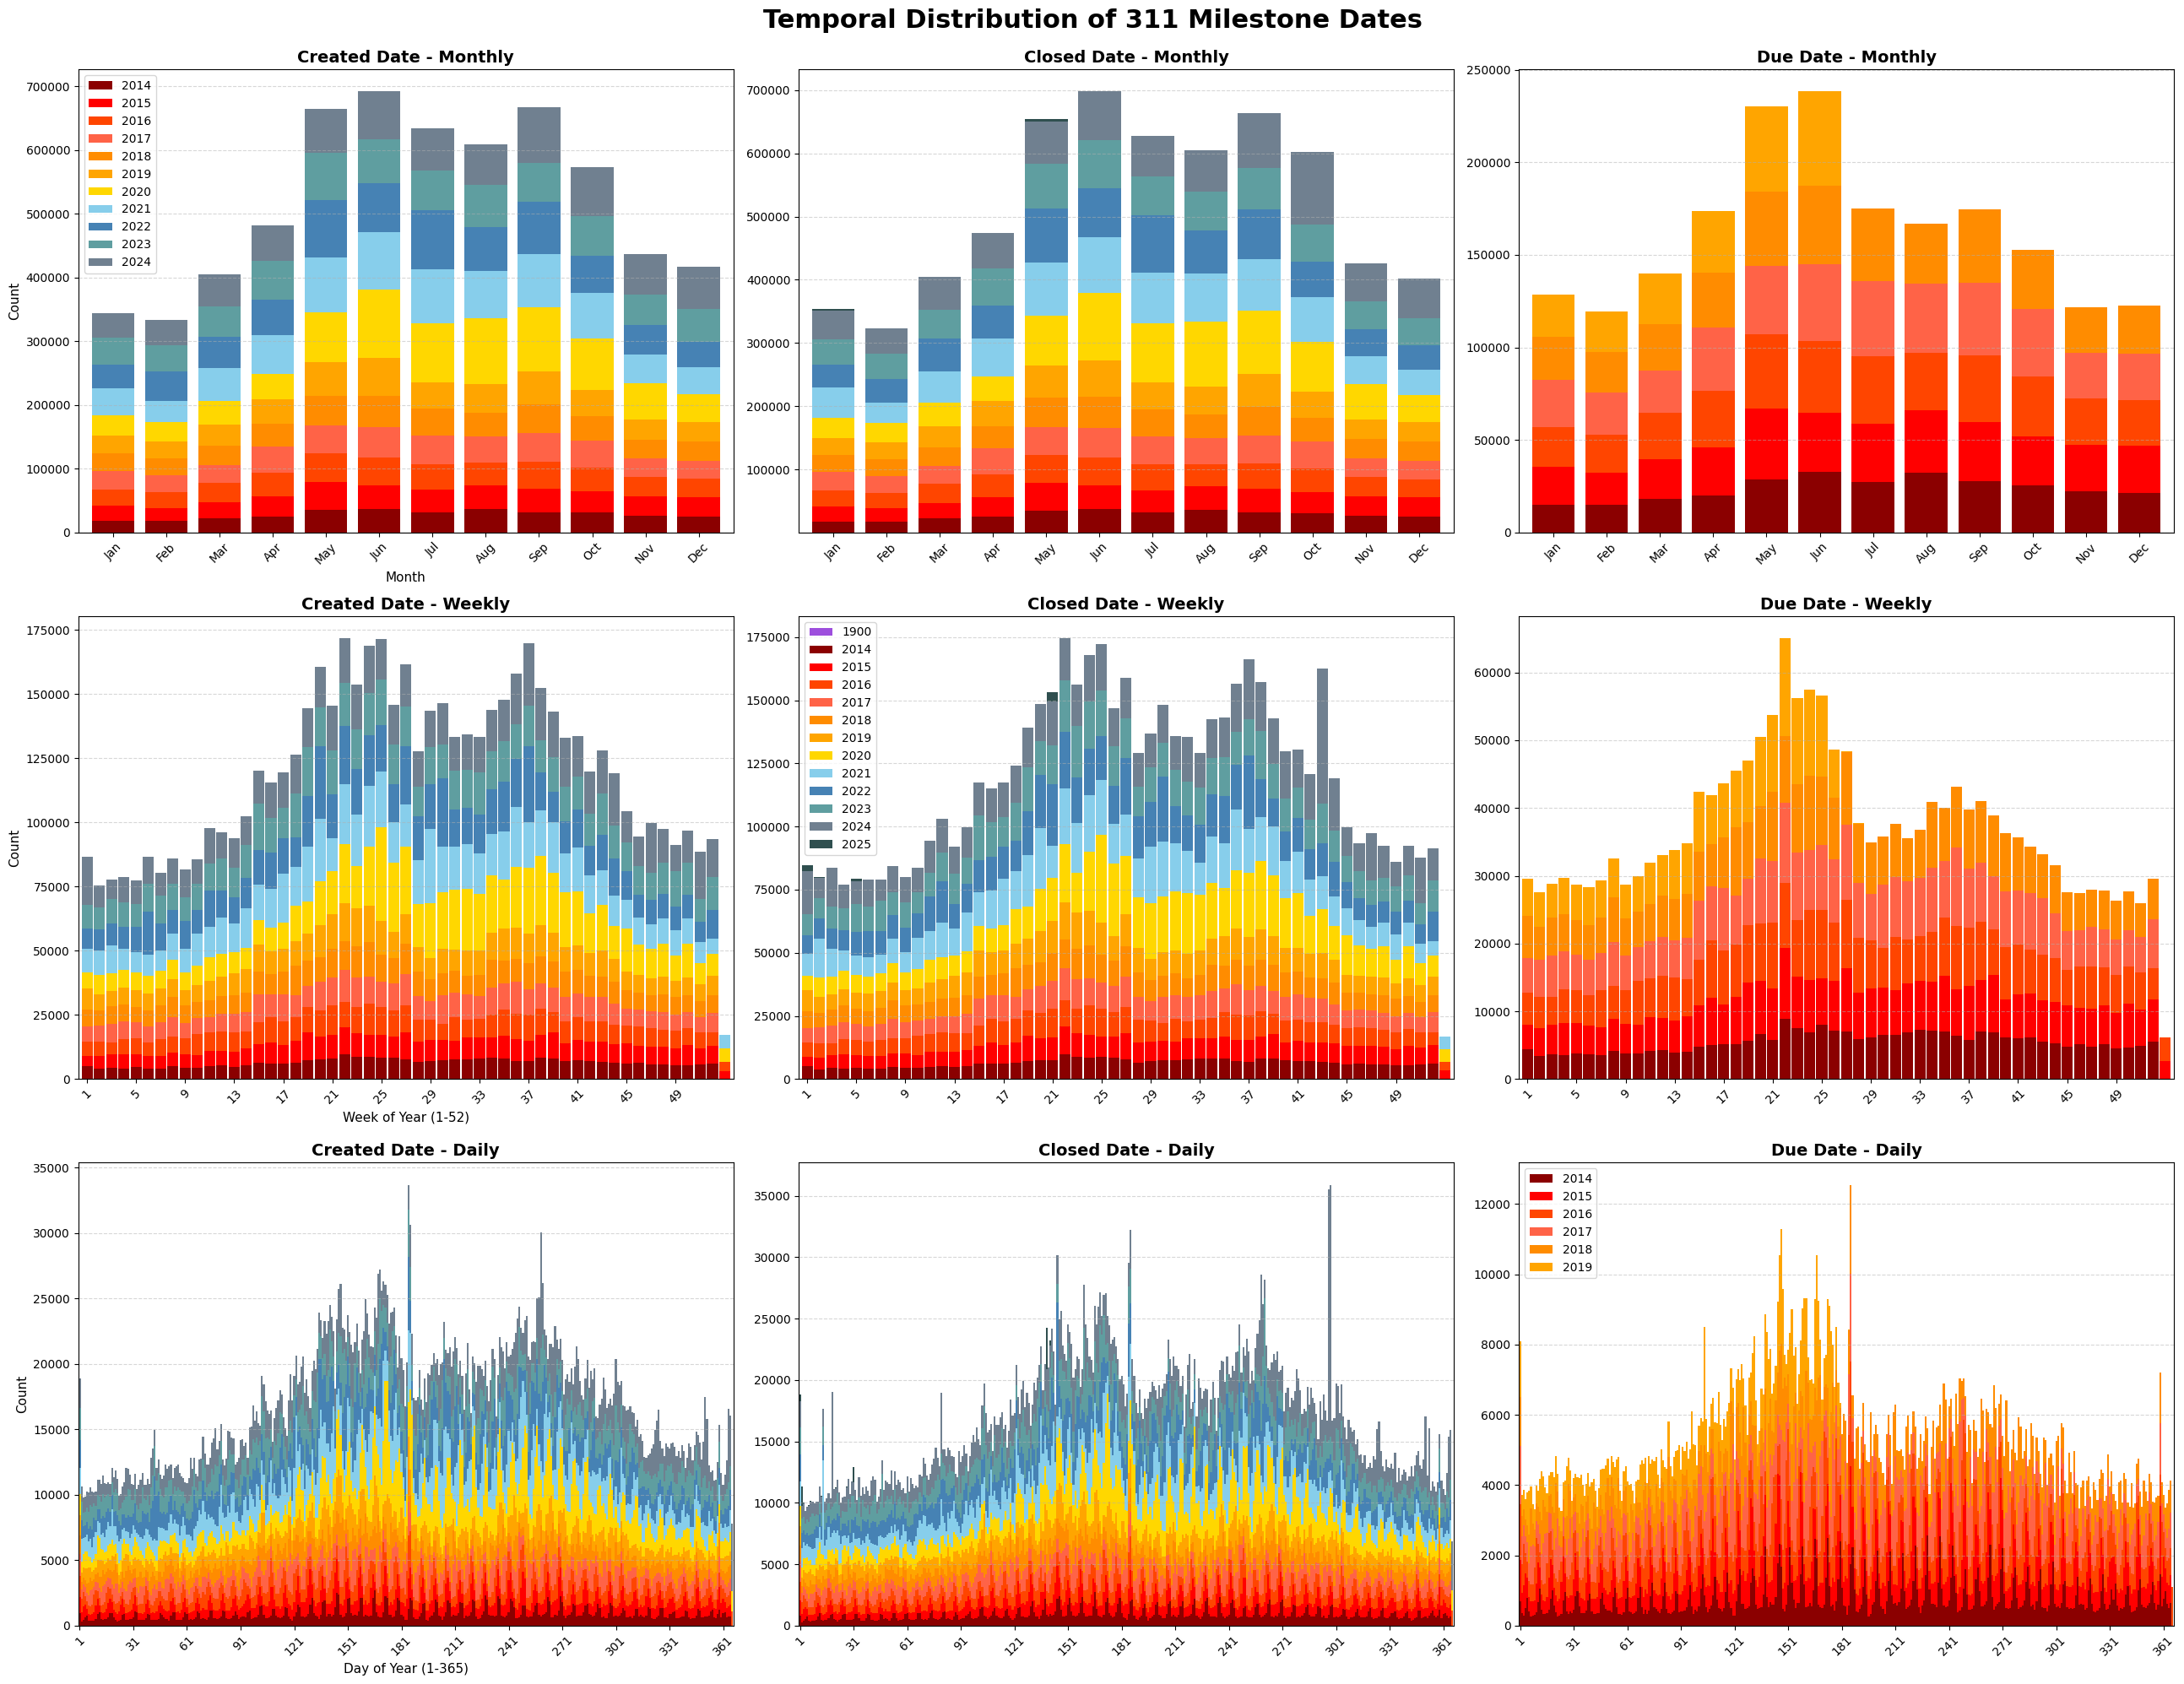

In [20]:
#create 3x3 figure
fig, axes = plt.subplots(3, 3, figsize=(26, 20))

#custom color list with purple for placeholder values (1900 etc)
neon_colors_with_placeholder = ['#9D4EDD'] + neon_colors  #for unknown, then regular neon colors

#ROW 1: MONTH
#CREATED - MONTH (0,0) - SHOW LEGEND (diagonal)
created_month_pivot = df_copy.groupby(['Created_Month', 'Created_Year']).size().unstack(fill_value=0)
created_month_pivot.plot(kind='bar', stacked=True, ax=axes[0, 0], width=0.8, color=neon_colors[:created_month_pivot.shape[1]])
axes[0, 0].set_title('Created Date - Monthly', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Month', fontsize=11)
axes[0, 0].set_ylabel('Count', fontsize=11)
axes[0, 0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
axes[0, 0].legend(title='', loc='upper left', fontsize=10, labels=[int(col) for col in created_month_pivot.columns])
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.5)

#CLOSED - MONTH (0,1) - HIDE LEGEND
closed_month_pivot = df_copy.groupby(['Closed_Month', 'Closed_Year']).size().unstack(fill_value=0)
closed_month_pivot.plot(kind='bar', stacked=True, ax=axes[0, 1], width=0.8, color=neon_colors_with_placeholder[:closed_month_pivot.shape[1]], legend=False)
axes[0, 1].set_title('Closed Date - Monthly', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('', fontsize=11)
axes[0, 1].set_ylabel('', fontsize=11)
axes[0, 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.5)

#DUE - MONTH (0,2) - HIDE LEGEND
due_month_pivot = df_copy.groupby(['Due_Month', 'Due_Year']).size().unstack(fill_value=0)
due_month_pivot.plot(kind='bar', stacked=True, ax=axes[0, 2], width=0.8, color=neon_colors[:due_month_pivot.shape[1]], legend=False)
axes[0, 2].set_title('Due Date - Monthly', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('', fontsize=11)
axes[0, 2].set_ylabel('', fontsize=11)
axes[0, 2].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
axes[0, 2].grid(axis='y', linestyle='--', alpha=0.5)

#ROW 2: WEEK
#CREATED - WEEK (1,0) - HIDE LEGEND
created_week_pivot = df_copy.groupby(['Created_WeekOfYear', 'Created_Year']).size().unstack(fill_value=0)
created_week_pivot.plot(kind='bar', stacked=True, ax=axes[1, 0], width=0.9, color=neon_colors[:created_week_pivot.shape[1]], legend=False)
axes[1, 0].set_title('Created Date - Weekly', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Week of Year (1-52)', fontsize=11)
axes[1, 0].set_ylabel('Count', fontsize=11)
axes[1, 0].set_xticks(range(0, 52, 4))
axes[1, 0].set_xticklabels(range(1, 53, 4), rotation=45)
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.5)

#CLOSED - WEEK (1,1) - SHOW LEGEND (diagonal)
closed_week_pivot = df_copy.groupby(['Closed_WeekOfYear', 'Closed_Year']).size().unstack(fill_value=0)
closed_week_pivot.plot(kind='bar', stacked=True, ax=axes[1, 1], width=0.9, color=neon_colors_with_placeholder[:closed_week_pivot.shape[1]])
axes[1, 1].set_title('Closed Date - Weekly', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('', fontsize=11)
axes[1, 1].set_ylabel('', fontsize=11)
axes[1, 1].set_xticks(range(0, 52, 4))
axes[1, 1].set_xticklabels(range(1, 53, 4), rotation=45)
axes[1, 1].legend(title='', loc='upper left', fontsize=10, labels=[int(col) for col in closed_week_pivot.columns])
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.5)

#DUE - WEEK (1,2) - HIDE LEGEND
due_week_pivot = df_copy.groupby(['Due_WeekOfYear', 'Due_Year']).size().unstack(fill_value=0)
due_week_pivot.plot(kind='bar', stacked=True, ax=axes[1, 2], width=0.9, color=neon_colors[:due_week_pivot.shape[1]], legend=False)
axes[1, 2].set_title('Due Date - Weekly', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('', fontsize=11)
axes[1, 2].set_ylabel('', fontsize=11)
axes[1, 2].set_xticks(range(0, 52, 4))
axes[1, 2].set_xticklabels(range(1, 53, 4), rotation=45)
axes[1, 2].grid(axis='y', linestyle='--', alpha=0.5)

#ROW 3: DAY
#CREATED - DAY (2,0) - HIDE LEGEND
created_day_pivot = df_copy.groupby(['Created_DayOfYear', 'Created_Year']).size().unstack(fill_value=0)
created_day_pivot.plot(kind='bar', stacked=True, ax=axes[2, 0], width=1.0, color=neon_colors[:created_day_pivot.shape[1]], legend=False)
axes[2, 0].set_title('Created Date - Daily', fontsize=14, fontweight='bold')
axes[2, 0].set_xlabel('Day of Year (1-365)', fontsize=11)
axes[2, 0].set_ylabel('Count', fontsize=11)
axes[2, 0].set_xticks(range(0, 365, 30))
axes[2, 0].set_xticklabels(range(1, 366, 30), rotation=45)
axes[2, 0].grid(axis='y', linestyle='--', alpha=0.5)

#CLOSED - DAY (2,1) - HIDE LEGEND
closed_day_pivot = df_copy.groupby(['Closed_DayOfYear', 'Closed_Year']).size().unstack(fill_value=0)
closed_day_pivot.plot(kind='bar', stacked=True, ax=axes[2, 1], width=1.0, color=neon_colors_with_placeholder[:closed_day_pivot.shape[1]], legend=False)
axes[2, 1].set_title('Closed Date - Daily', fontsize=14, fontweight='bold')
axes[2, 1].set_xlabel('', fontsize=11)
axes[2, 1].set_ylabel('', fontsize=11)
axes[2, 1].set_xticks(range(0, 365, 30))
axes[2, 1].set_xticklabels(range(1, 366, 30), rotation=45)
axes[2, 1].grid(axis='y', linestyle='--', alpha=0.5)

#DUE - DAY (2,2) - SHOW LEGEND (diagonal)
due_day_pivot = df_copy.groupby(['Due_DayOfYear', 'Due_Year']).size().unstack(fill_value=0)
due_day_pivot.plot(kind='bar', stacked=True, ax=axes[2, 2], width=1.0, color=neon_colors[:due_day_pivot.shape[1]])
axes[2, 2].set_title('Due Date - Daily', fontsize=14, fontweight='bold')
axes[2, 2].set_xlabel('', fontsize=11)
axes[2, 2].set_ylabel('', fontsize=11)
axes[2, 2].set_xticks(range(0, 365, 30))
axes[2, 2].set_xticklabels(range(1, 366, 30), rotation=45)
axes[2, 2].legend(title='', loc='upper left', fontsize=10, labels=[int(col) for col in due_day_pivot.columns])
axes[2, 2].grid(axis='y', linestyle='--', alpha=0.5)

#Main title
fig.suptitle('Temporal Distribution of 311 Milestone Dates', 
             fontsize=22, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

### 2.7 Examination of 311 Duration (Created to Close)
This code calculates how many days each complaint took to close by subtracting the creation date from the closure date. It stores these values in a new column called Duration_Days. It prints summary statistics and counts of records with and without duration data.

In [21]:
#calc duration in days from Created Date to Closed Date
#gives us the number of days between when a complaint was created and when it was closed
df_copy['Duration_Days'] = (df_copy['Closed Date'] - df_copy['Created Date']).dt.days

#show summary statistics
print("Duration Statistics (in days):")
print(df_copy['Duration_Days'].describe())
print('==='*10)
print(f"\nRecords with duration data: {df_copy['Duration_Days'].notna().sum():,}")
print(f"Records missing duration data: {df_copy['Duration_Days'].isna().sum():,}")

Duration Statistics (in days):
count    6.233256e+06
mean     7.499882e+00
std      8.837070e+01
min     -4.290200e+04
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.932000e+03
Name: Duration_Days, dtype: float64

Records with duration data: 6,233,256
Records missing duration data: 26,992


#### Data Viz -- 311 Duration (Days)
This code creates a figure with two vertically stacked histograms showing complaint closure durations. The first plot visualizes the full range of durations from 0 to 365 days, with counts labeled on each bar. The second plot zooms in on short durations from 0 to 15 days, again labeling counts, to highlight the distribution of quickly resolved complaints.

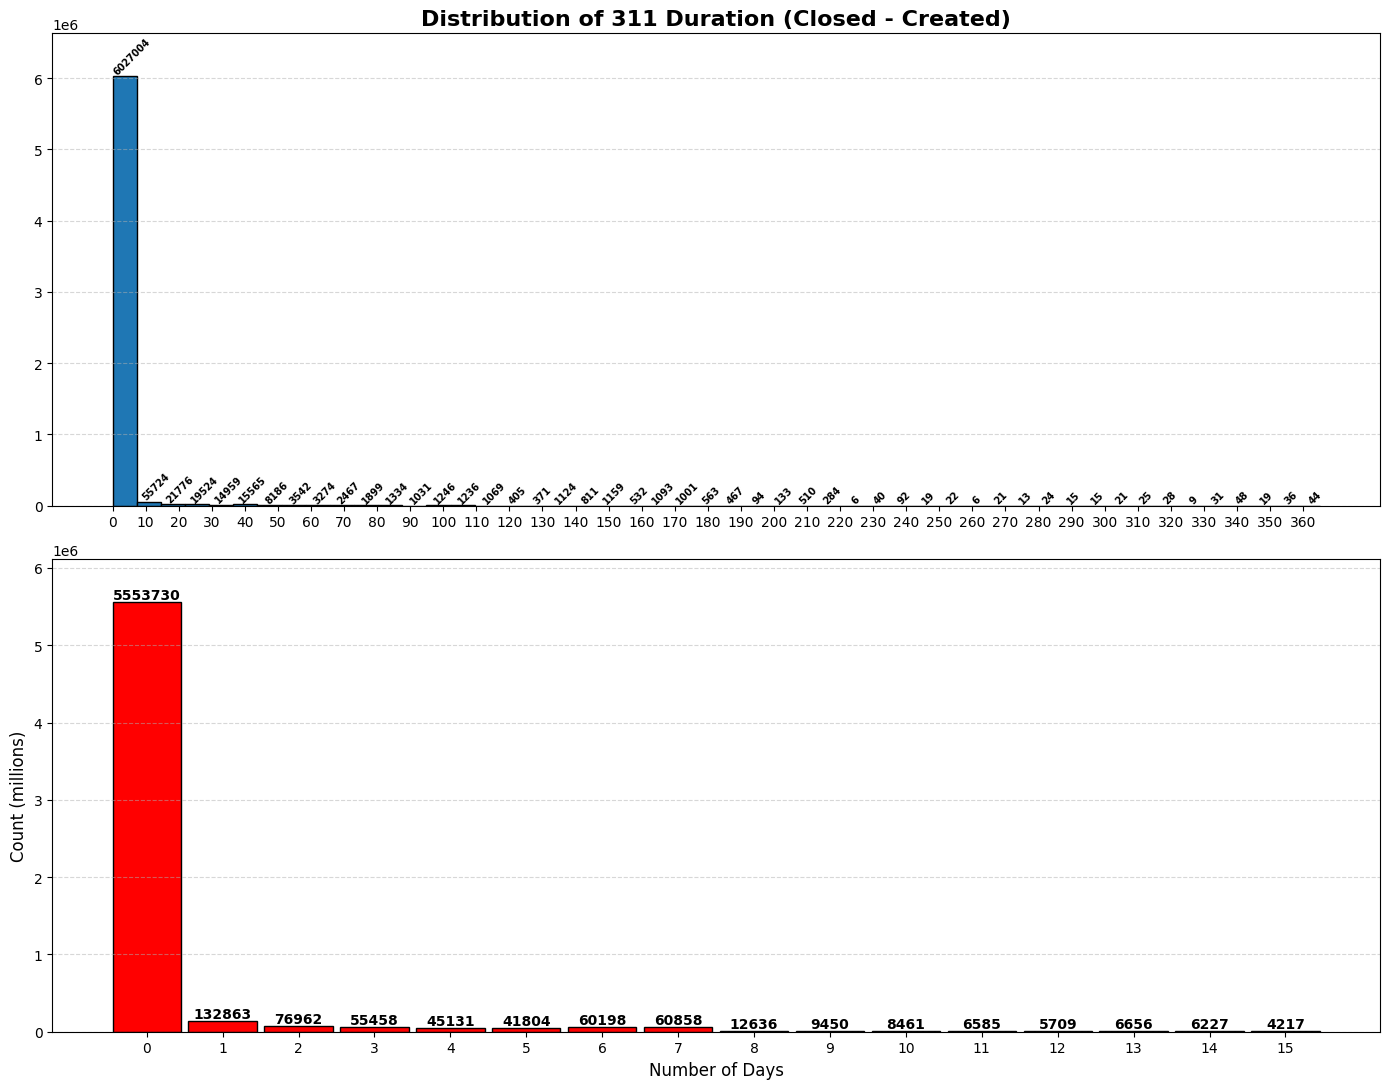

In [43]:
#figure with 2 subplots stacked vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11))

#FIRST PLOT -- all (0-365 days)
#remove NaN and filter reasonable range for visualization
duration_clean_1 = df_copy['Duration_Days'].dropna()
duration_clean_1 = duration_clean_1[(duration_clean_1 >= 0) & (duration_clean_1 <= 365)]

#histogram and get the counts
counts_1, bins_1, patches_1 = ax1.hist(duration_clean_1, bins=50, edgecolor='black')

#add value labels on top of bars - shifted left
for i, (count, patch) in enumerate(zip(counts_1, patches_1)):
    if count > 0:  #label non-zero bars
        height = patch.get_height()
        x_position = patch.get_x() + patch.get_width()/2. + patch.get_width()*0.3
        ax1.text(x_position, height,
                f'{int(count)}',
                ha='center', va='bottom', fontsize=7, rotation=45, fontweight='bold')

#add space to the y-axis
y_max_1 = counts_1.max()
ax1.set_ylim(0, y_max_1 * 1.1)

#x-axis ticks
ax1.set_xticks(range(0, 366, 10))

ax1.set_title('Distribution of 311 Duration (Closed - Created)', fontsize=16, fontweight='bold')
ax1.set_xlabel('', fontsize=12)
ax1.set_ylabel('', fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

#SECOND PLOT only (0-15 days)
#remove NaN and filter reasonable range for visualization
duration_clean_2 = df_copy['Duration_Days'].dropna()
duration_clean_2 = duration_clean_2[(duration_clean_2 >= 0) & (duration_clean_2 <= 15)]

#histogram with bins aligned to integers (0, 1, 2, ..., 15)
bins_aligned = np.arange(0, 16.5, 1)  #bins: [0-1), [1-2), ..., [15-16)
counts_2, bins_2, patches_2 = ax2.hist(duration_clean_2, bins=bins_aligned, 
                                        edgecolor='black', color='red', rwidth=0.9)

#value labels on top of bars
for i, (count, patch) in enumerate(zip(counts_2, patches_2)):
    if count > 0:  # Only label non-zero bars
        height = patch.get_height()
        x_position = patch.get_x() + patch.get_width()/2. 
        ax2.text(x_position, height,
                f'{int(count)}',
                ha='center', va='bottom', fontsize=10, rotation=0, fontweight='bold')

#add space to the y-axis
y_max_2 = counts_2.max()
ax2.set_ylim(0, y_max_2 * 1.1)

#set x-axis ticks to align with bar centers (0.5, 1.5, 2.5, etc.)
ax2.set_xticks(np.arange(0.5, 16, 1))
ax2.set_xticklabels(range(0, 16, 1))

ax2.set_title('', fontsize=16, fontweight='bold')
ax2.set_xlabel('Number of Days', fontsize=12)
ax2.set_ylabel('Count (millions)', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 2.8 Year-Over-Year Examination of Noise Complaints
This code creates a 2×2 grid of line charts showing yearly trends in NYC 311 noise complaints. The top-left plot shows total complaint volume per year, while the top-right breaks it down by complaint type. The bottom-left compares trends across boroughs, and the bottom-right shows patterns by responding agency. Each subplot includes labeled lines, legends in the upper left, and a shared title summarizing the analysis.

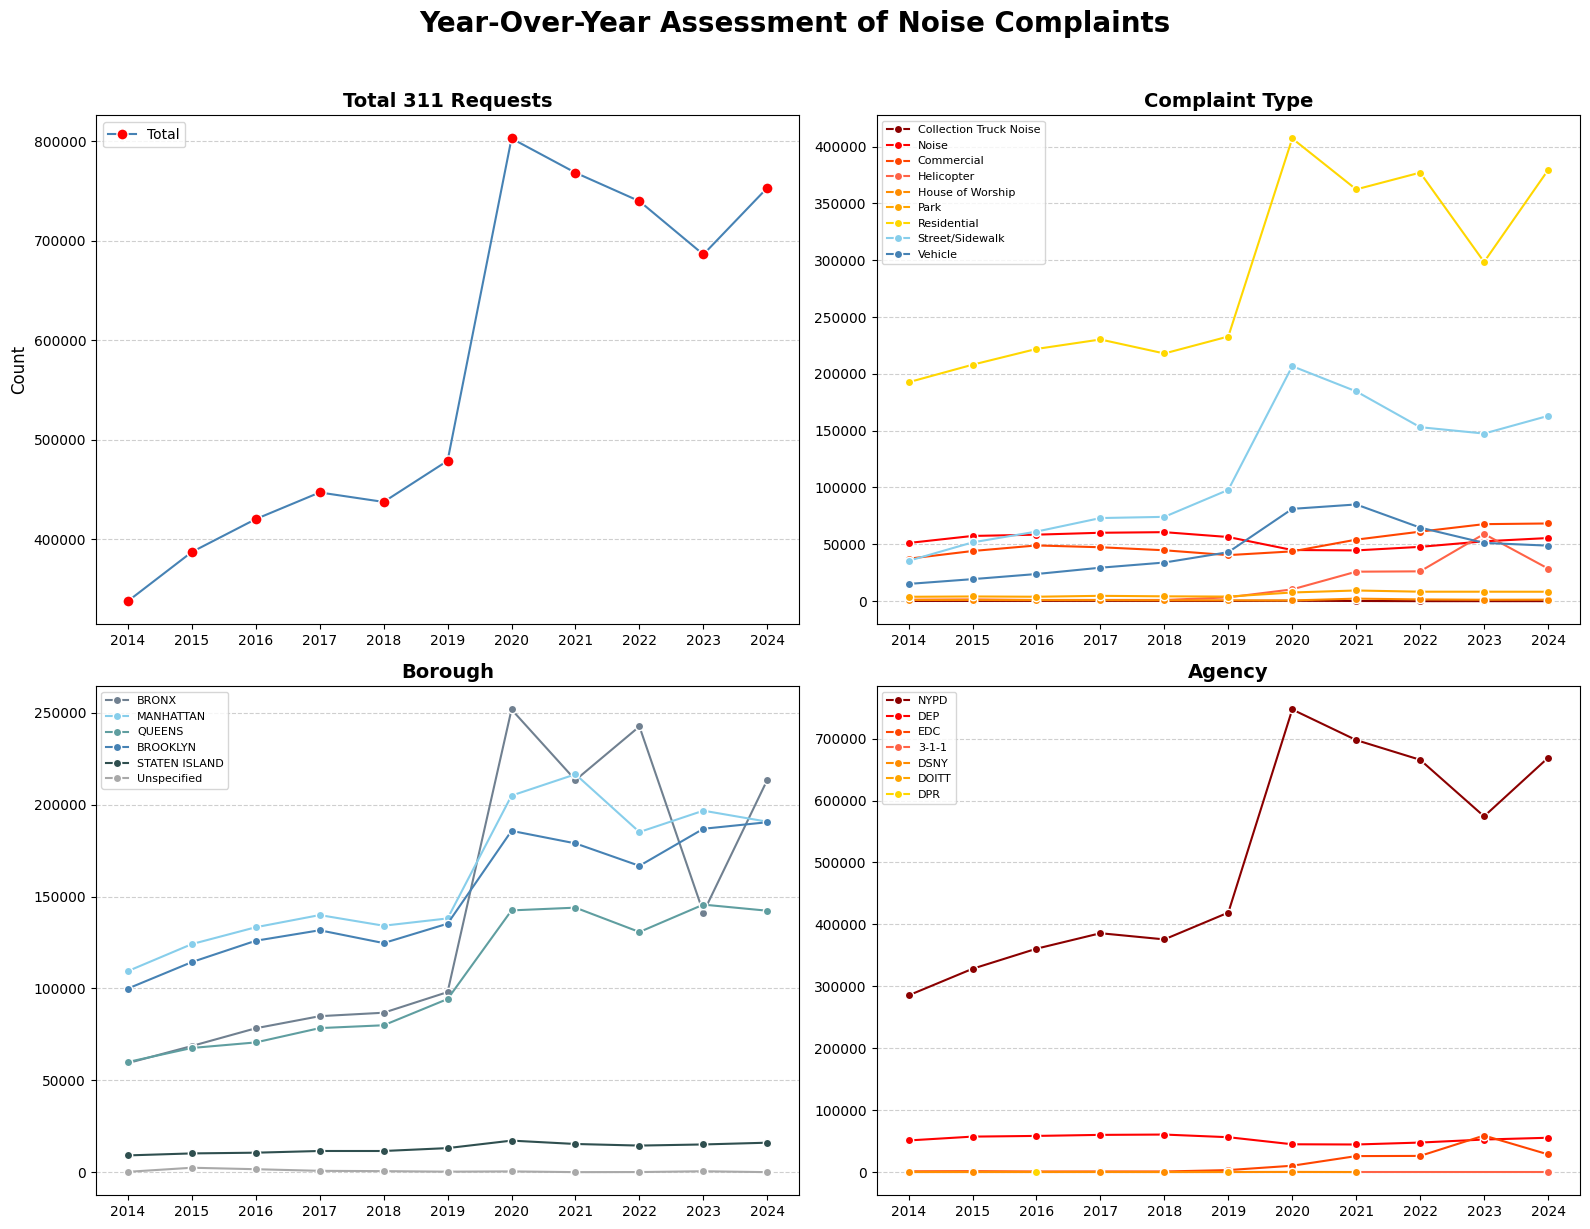

In [49]:
#figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
#main title
fig.suptitle('Year-Over-Year Assessment of Noise Complaints', fontsize=20, fontweight='bold', y=1.02)
#flat axes for easy indexing
axes = axes.flatten()

#TOP LEFT -- Total 311 requests
yearly_counts = df_copy.groupby('Created_Year').size()
axes[0].plot(yearly_counts.index, yearly_counts.values, marker='o', linestyle='-', color='#4682b4', markerfacecolor='#FF0000', markeredgecolor='white', markersize=8)
axes[0].set_title('Total 311 Requests', fontsize=14, fontweight='bold')
axes[0].set_xlabel('', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticks(yearly_counts.index)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)
axes[0].legend(['Total'], loc='upper left')

#TOP RIGHT -- Complaint Type
complaint_yearly = df_copy.groupby(['Created_Year', 'Complaint Type']).size().unstack(fill_value=0)
for i, complaint in enumerate(complaint_yearly.columns):
    color = neon_colors[i % len(neon_colors)]
    clean_label = complaint.replace('Noise - ', '')
    axes[1].plot(complaint_yearly.index, complaint_yearly[complaint], marker='o', label=clean_label, color=color, markeredgecolor='white')
axes[1].set_title('Complaint Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('', fontsize=12)
axes[1].set_ylabel('', fontsize=12)
axes[1].set_xticks(complaint_yearly.index)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)
axes[1].legend(title='', loc='upper left', fontsize=8)

#BOTTOM LEFT -- Borough
#mapping function from full names to abbreviations
borough_abbr_map = {
    'MANHATTAN': 'MN',
    'BROOKLYN': 'BK',
    'QUEENS': 'QN',
    'BRONX': 'BX',
    'STATEN ISLAND': 'SI',
    'Unspecified': 'Unspecified'
}

boroughs = df_copy['Borough'].dropna().unique()
for borough in boroughs:
    df_boro = df_copy[df_copy['Borough'] == borough]
    yearly_counts_boro = df_boro.groupby('Created_Year').size()
    borough_abbr = borough_abbr_map.get(borough, borough)
    color = borough_color_map.get(borough_abbr, '#808080')
    axes[2].plot(yearly_counts_boro.index, yearly_counts_boro.values, marker='o', linestyle='-', label=borough, color=color, markeredgecolor='white')
axes[2].set_title('Borough', fontsize=14, fontweight='bold')
axes[2].set_xlabel('', fontsize=12)
axes[2].set_ylabel('', fontsize=12)
axes[2].set_xticks(sorted(df_copy['Created_Year'].dropna().unique()))
axes[2].grid(axis='y', linestyle='--', alpha=0.6)
axes[2].legend(title='', loc='upper left', fontsize=8)

#BOTTOM RIGHT -- Agency
agencies = df_copy['Agency'].dropna().unique()
for i, agency in enumerate(agencies):
    df_agency = df_copy[df_copy['Agency'] == agency]
    yearly_counts_agency = df_agency.groupby('Created_Year').size()
    color = neon_colors[i % len(neon_colors)]
    axes[3].plot(yearly_counts_agency.index, yearly_counts_agency.values, marker='o', linestyle='-', label=agency, color=color, markeredgecolor='white')
axes[3].set_title('Agency', fontsize=14, fontweight='bold')
axes[3].set_xlabel('', fontsize=12)
axes[3].set_ylabel('', fontsize=12)
axes[3].set_xticks(sorted(df_copy['Created_Year'].dropna().unique()))
axes[3].grid(axis='y', linestyle='--', alpha=0.6)
axes[3].legend(title='', loc='upper left', fontsize=8)

#layout
plt.tight_layout()
plt.show()

#### Borough-Level Review
This code creates a grid of subplots showing yearly noise complaint trends for each NYC borough.
Each subplot displays lines for different complaint types within that borough.
Legends appear only in the first subplot, and all charts share the same y-axis scale for easier comparison.
The figure includes a main title summarizing the borough-level year-over-year analysis.

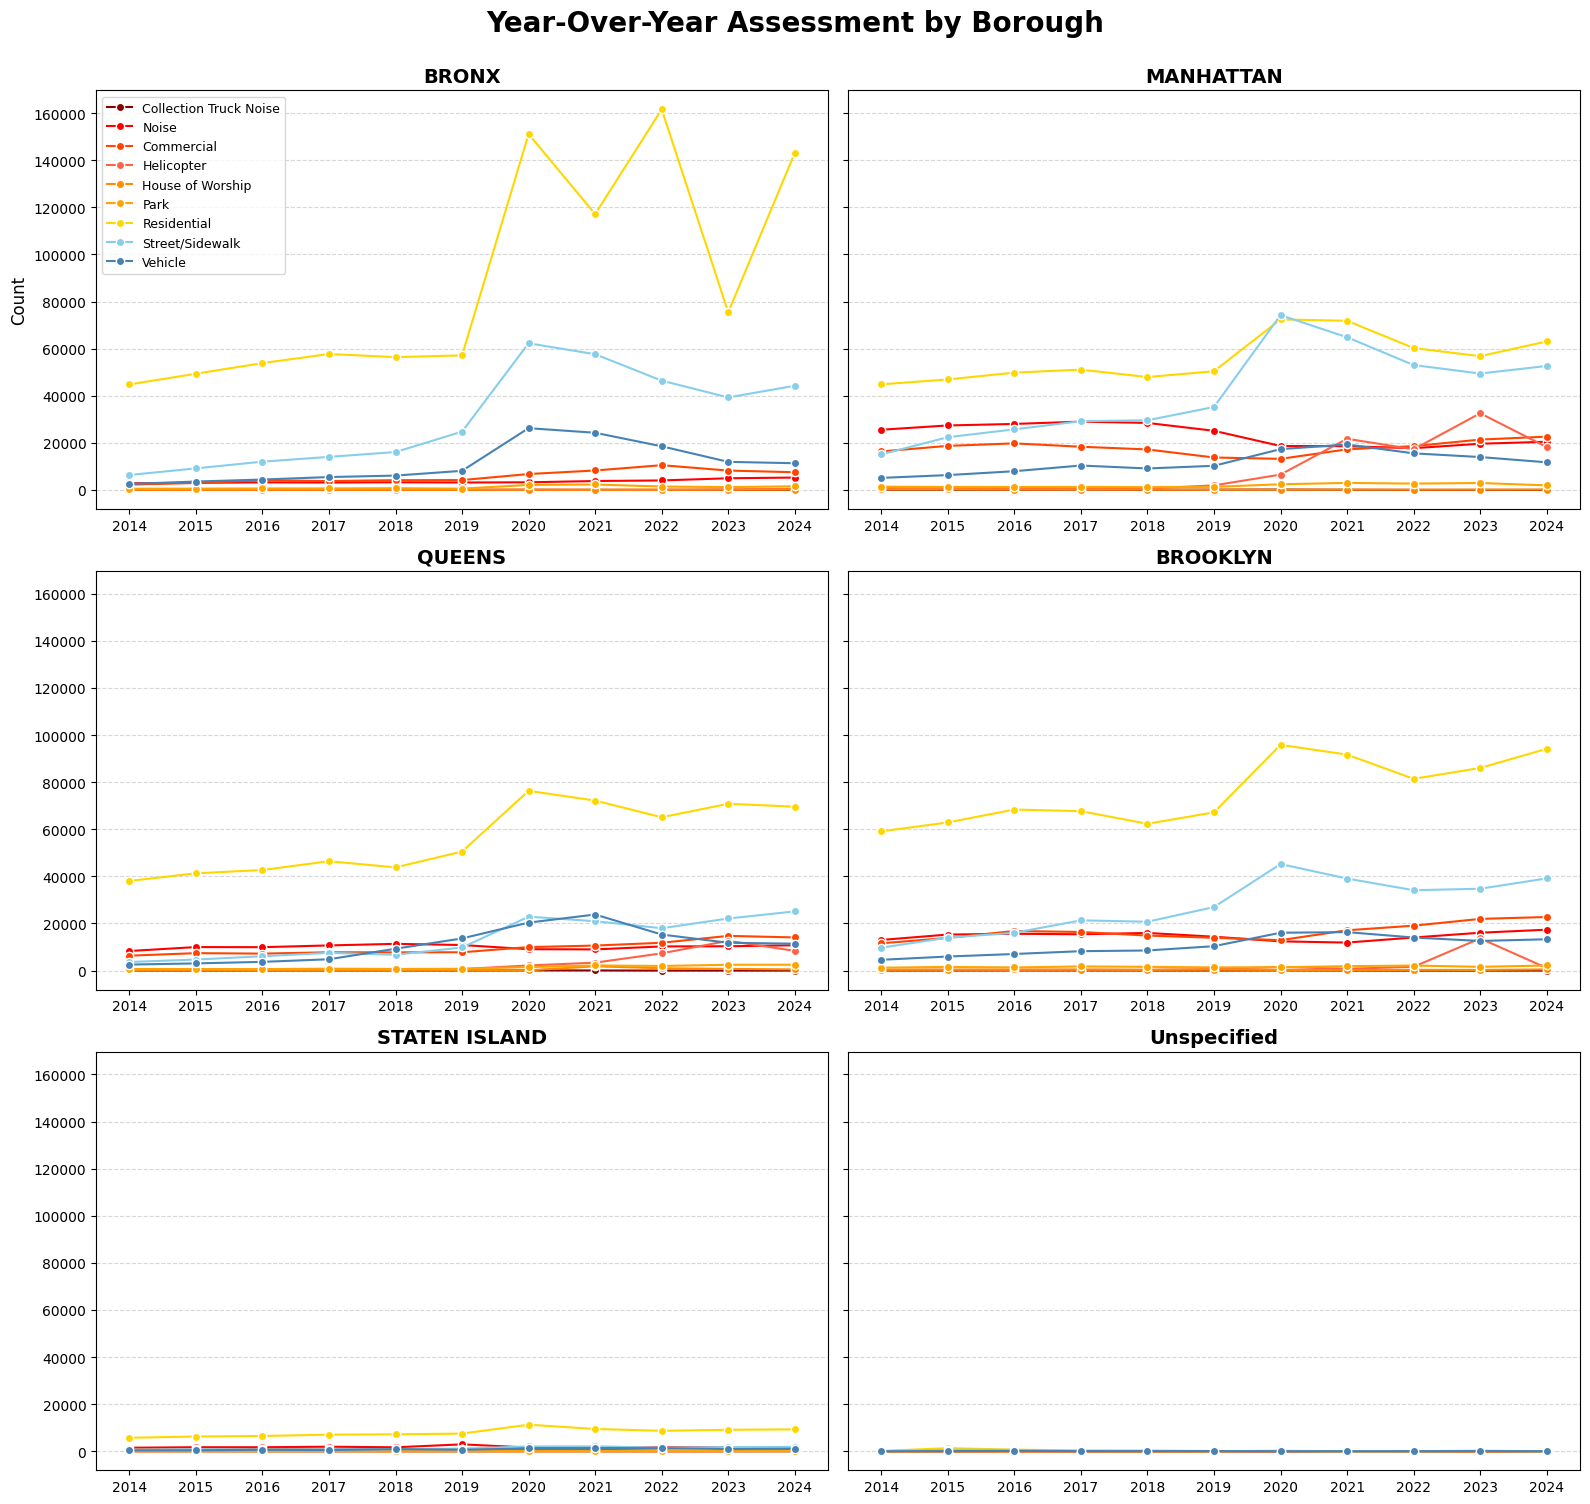

In [71]:
#get unique boroughs
boroughs = df_copy['Borough'].dropna().unique()
num_boroughs = len(boroughs)

#set subplot grid size
ncols = 2
nrows = (num_boroughs + 1) // ncols  # ceil division

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 5), sharey=True) #avoid repeat labeled y axis

#main title
fig.suptitle('Year-Over-Year Assessment by Borough', fontsize=20, fontweight='bold', y=1.00)

axes = axes.flatten()  #in case we have multiple rows

#LOOP through each borough and plot
for i, borough in enumerate(boroughs):
    ax = axes[i]
    #filter data for the borough
    df_boro = df_copy[df_copy['Borough'] == borough]
    #group by year and complaint type
    complaint_yearly = df_boro.groupby(['Created_Year', 'Complaint Type']).size().unstack(fill_value=0)
    
    #plot for each complaint type
    for j, complaint in enumerate(complaint_yearly.columns):
        color = neon_colors[j % len(neon_colors)]
        clean_label = complaint.replace('Noise - ', '')
        ax.plot(complaint_yearly.index, complaint_yearly[complaint], marker='o', label=clean_label, color=color, markeredgecolor='white')
    
    ax.set_title(f'{borough}', fontsize=14, fontweight='bold')
    ax.set_xlabel('', fontsize=12)
    
    #add y-axis label to first plot
    if i == 0:
        ax.set_ylabel('Count', fontsize=12)
    else:
        ax.set_ylabel('', fontsize=12)
    
    ax.set_xticks(complaint_yearly.index)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    #show legend in first plot
    if i == 0:
        ax.legend(fontsize=9, title='', loc='upper left')

#strip any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### COMMUNITY BOARDS
This code visualizes year-over-year noise complaint trends for each community board.
Each subplot represents one community board, showing lines for different complaint types over time.
A shared legend (in the final subplot) identifies complaint types, and all charts share a consistent y-axis scale.
The figure title highlights that the analysis focuses specifically on a given borough. 

#### The Bronx

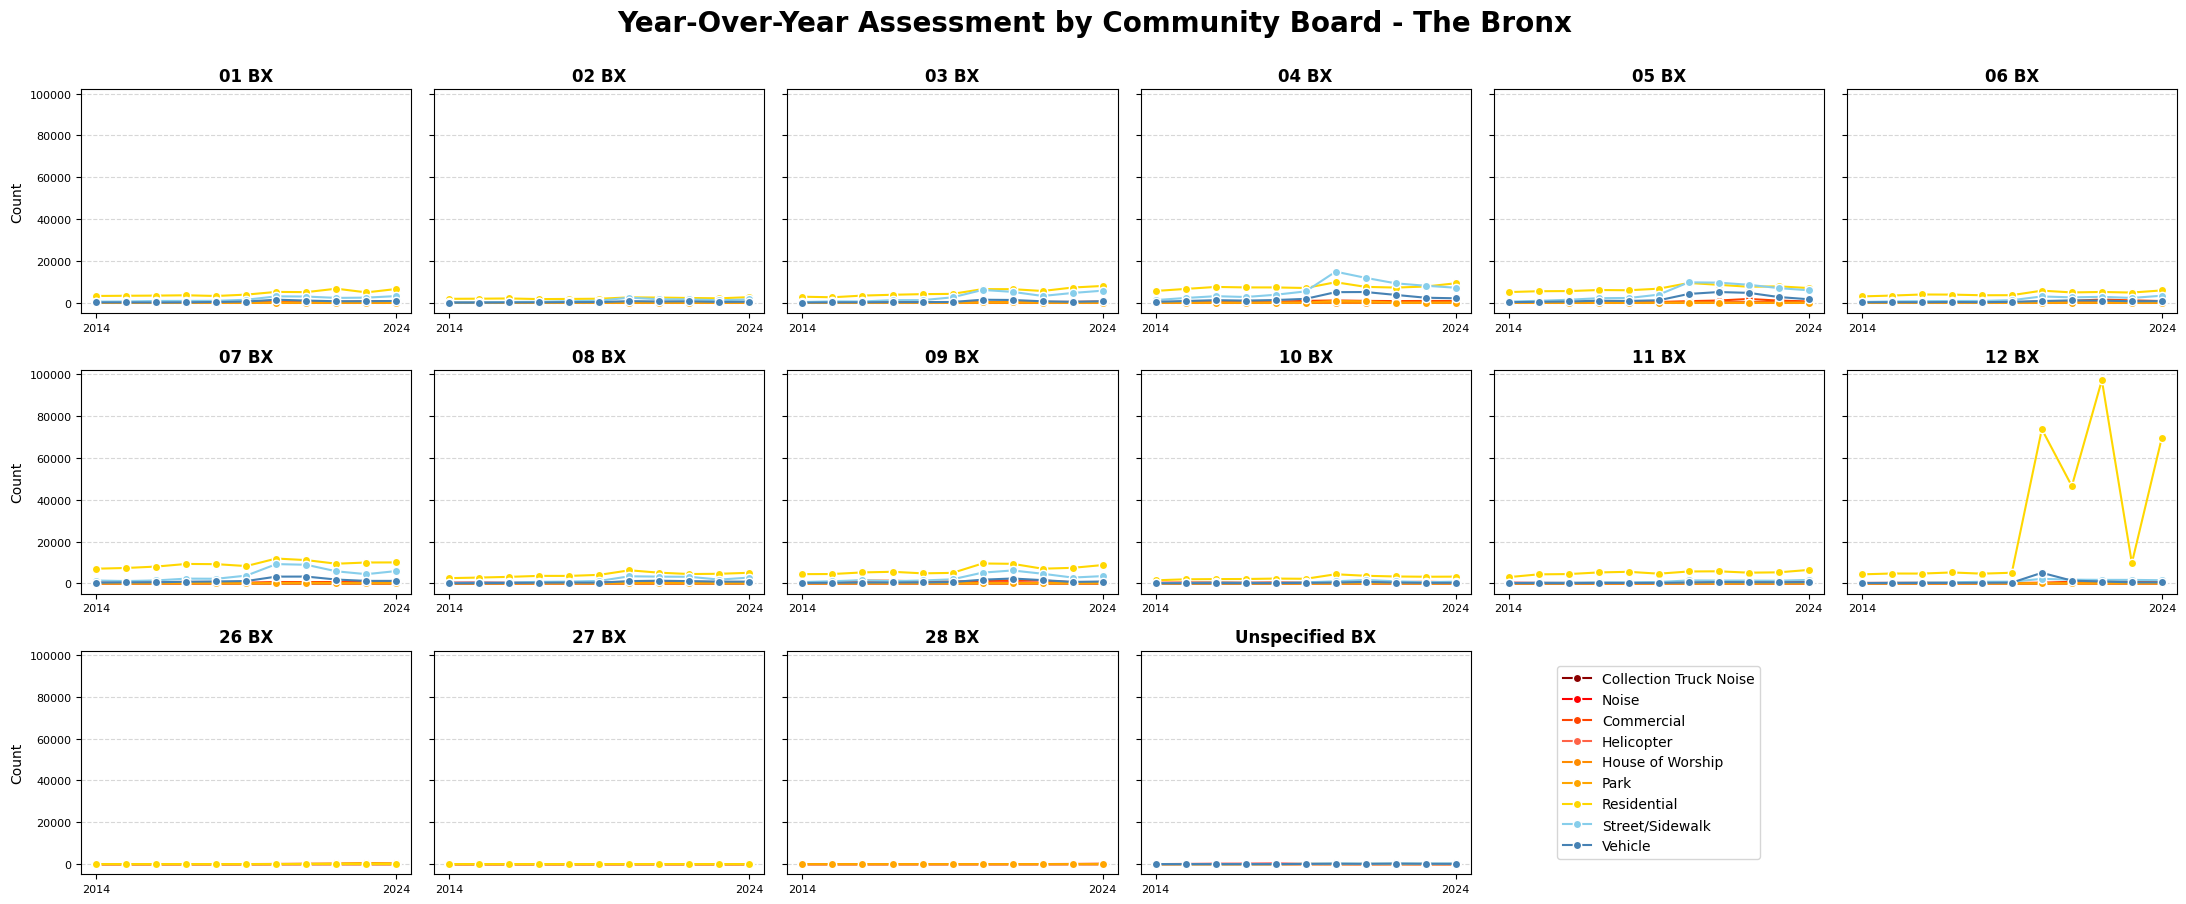

In [81]:
#filter for specific boro only
df_bronx = df_copy[df_copy['Borough'] == 'BRONX']

#unique community boards in Bronx (filter to only include BX boards)
community_boards = df_bronx['Community Board'].dropna().unique()
community_boards = sorted([board for board in community_boards if 'BRONX' in str(board)])
num_boards = len(community_boards)

#find index of 'Unspecified' if exists
unspecified_idx = None
for idx, board in enumerate(community_boards):
    if 'Unspecified' in board:
        unspecified_idx = idx
        break

#subplot grid size (add 1 for legend)
ncols = 6
nrows = int(np.ceil((num_boards + 1) / ncols))  # add 1 for legend subplot

fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 3), sharey=True)
axes = axes.flatten()  #flatten in case of multiple rows

#main title
fig.suptitle('Year-Over-Year Assessment by Community Board - The Bronx', fontsize=20, fontweight='bold', y=1.00)

#determine legend position: right after 'Unspecified' or first if not found
legend_pos = (unspecified_idx + 1) if unspecified_idx is not None else 0
ax_legend = axes[legend_pos]
ax_legend.axis('off')

#dummy plot for legend (use first community board as sample)
df_board_sample = df_bronx[df_bronx['Community Board'] == community_boards[0]]
complaint_yearly_sample = df_board_sample.groupby(['Created_Year', 'Complaint Type']).size().unstack(fill_value=0)

for j, complaint in enumerate(complaint_yearly_sample.columns):
    color = neon_colors[j % len(neon_colors)]
    clean_label = complaint.replace('Noise - ', '')
    ax_legend.plot([], [], marker='o', label=clean_label, color=color, markeredgecolor='white')

ax_legend.legend(fontsize=10, title='', loc='center', frameon=True)

#LOOP -- each community board and plot
for i, board in enumerate(community_boards):
    #skip legend subplot
    ax_idx = i if legend_pos > i else i + 1
    ax = axes[ax_idx]

    df_board = df_bronx[df_bronx['Community Board'] == board]
    complaint_yearly = df_board.groupby(['Created_Year', 'Complaint Type']).size().unstack(fill_value=0)

    for j, complaint in enumerate(complaint_yearly.columns):
        color = neon_colors[j % len(neon_colors)]
        clean_label = complaint.replace('Noise - ', '')
        ax.plot(complaint_yearly.index, complaint_yearly[complaint], marker='o', color=color, markeredgecolor='white')

    board_title = board.replace('BRONX', 'BX')
    ax.set_title(f'{board_title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('', fontsize=10)
    if ax_idx % ncols == 0:
        ax.set_ylabel('Count', fontsize=10)
    else:
        ax.set_ylabel('', fontsize=10)

    years = complaint_yearly.index.tolist()
    if years:
        ax.set_xticks([years[0], years[-1]])
    ax.tick_params(axis='both', labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

#strip unused axes
for j in range(num_boards + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Manhattan

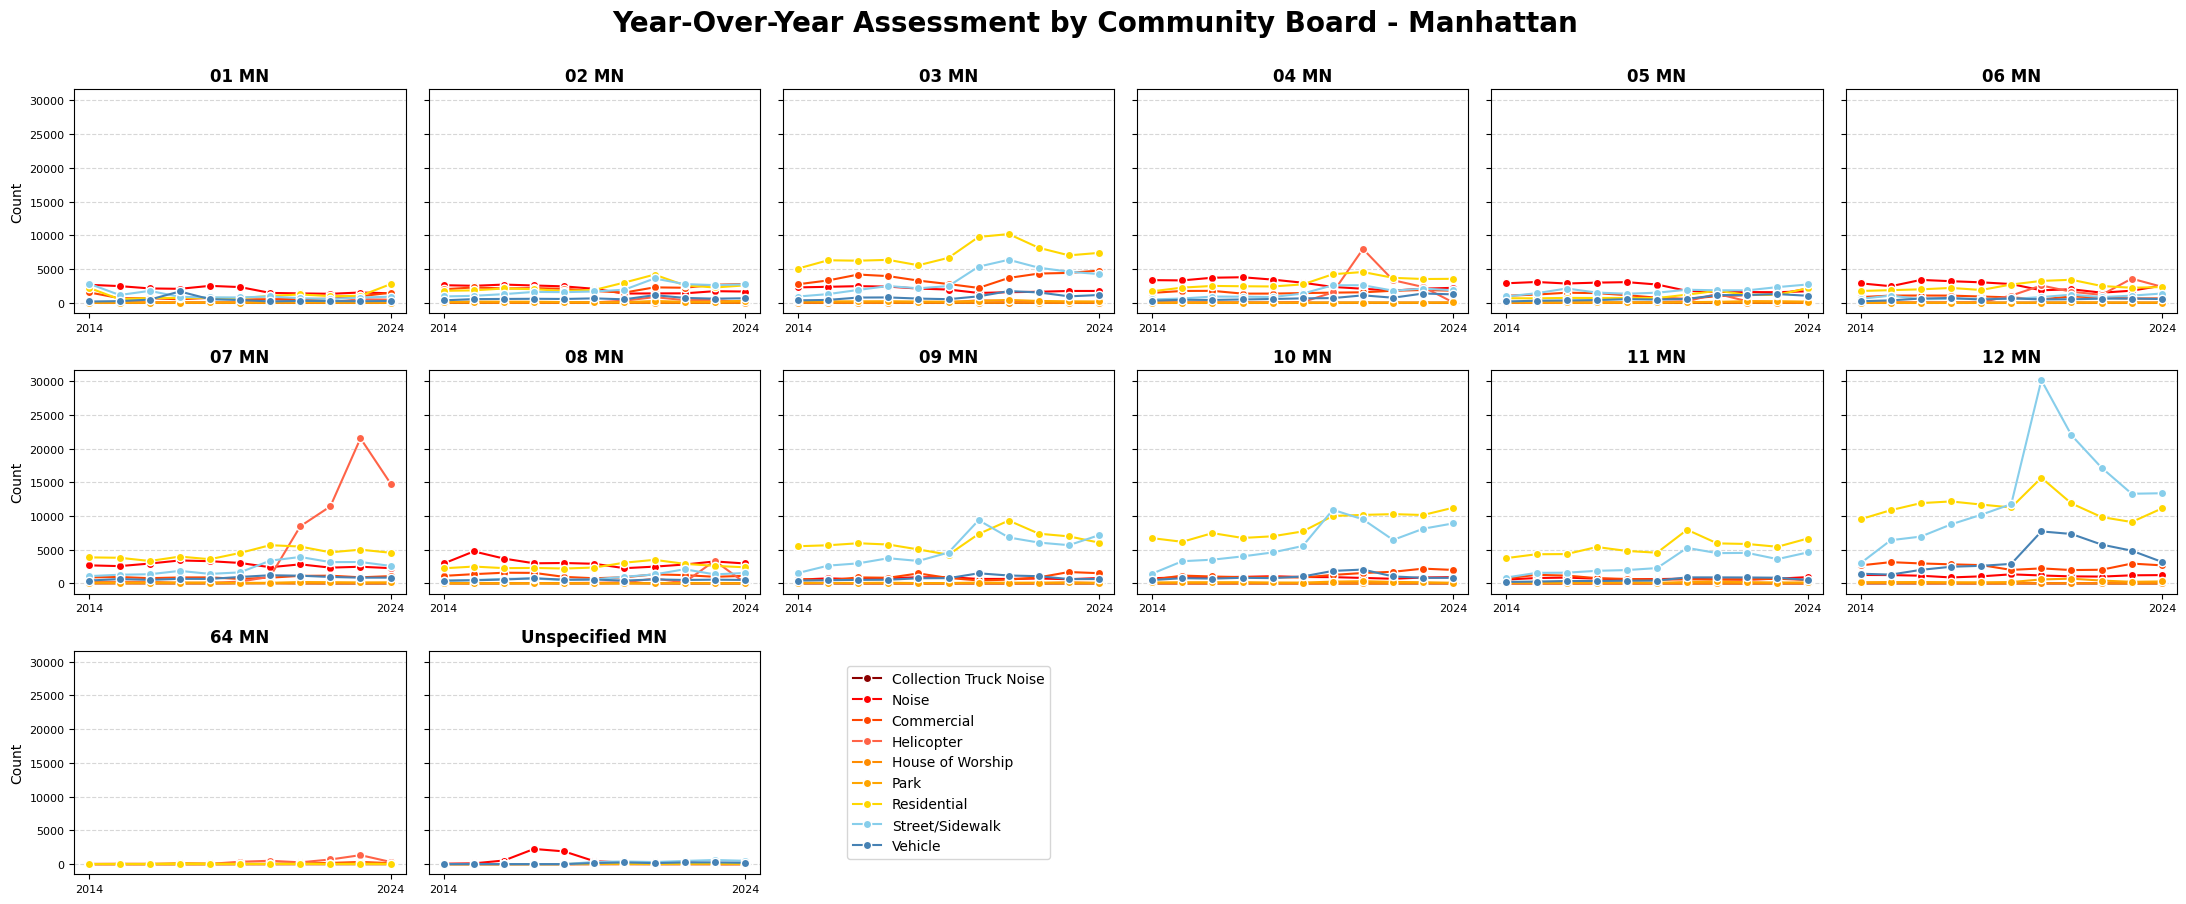

In [82]:
#filter for specific boro only
df_manhattan = df_copy[df_copy['Borough'] == 'MANHATTAN']

#unique community boards in boro
community_boards = df_manhattan['Community Board'].dropna().unique()
community_boards = sorted([board for board in community_boards if 'MANHATTAN' in str(board)])
num_boards = len(community_boards)

#find index of 'Unspecified' if exists
unspecified_idx = None
for idx, board in enumerate(community_boards):
    if 'Unspecified' in board:
        unspecified_idx = idx
        break

#subplot grid size (add 1 for legend subplot)
ncols = 6
nrows = int(np.ceil((num_boards + 1) / ncols))  # add 1 for legend

fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 3), sharey=True)
axes = axes.flatten()  #flatten in case of multiple rows

#main title
fig.suptitle('Year-Over-Year Assessment by Community Board - Manhattan',
             fontsize=20, fontweight='bold', y=1.00)

#determine legend position: right after 'Unspecified' or at end if none
legend_pos = (unspecified_idx + 1) if unspecified_idx is not None else num_boards
ax_legend = axes[legend_pos]
ax_legend.axis('off')

#dummy plot for legend (use first board as sample)
df_board_sample = df_manhattan[df_manhattan['Community Board'] == community_boards[0]]
complaint_yearly_sample = df_board_sample.groupby(['Created_Year', 'Complaint Type']).size().unstack(fill_value=0)

for j, complaint in enumerate(complaint_yearly_sample.columns):
    color = neon_colors[j % len(neon_colors)]
    clean_label = complaint.replace('Noise - ', '')
    ax_legend.plot([], [], marker='o', label=clean_label, color=color, markeredgecolor='white')

ax_legend.legend(fontsize=10, title='', loc='center', frameon=True)

#plot each community board
for i, board in enumerate(community_boards):
    #skip legend subplot
    ax_idx = i if legend_pos > i else i + 1
    ax = axes[ax_idx]

    df_board = df_manhattan[df_manhattan['Community Board'] == board]
    complaint_yearly = df_board.groupby(['Created_Year', 'Complaint Type']).size().unstack(fill_value=0)

    for j, complaint in enumerate(complaint_yearly.columns):
        color = neon_colors[j % len(neon_colors)]
        clean_label = complaint.replace('Noise - ', '')
        ax.plot(complaint_yearly.index, complaint_yearly[complaint],
                marker='o', color=color, markeredgecolor='white')

    board_title = board.replace('MANHATTAN', 'MN')
    ax.set_title(f'{board_title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count' if ax_idx % ncols == 0 else '')
    years = complaint_yearly.index
    ax.set_xticks([years[0], years[-1]])
    ax.tick_params(axis='both', labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

#remove unused axes
for j in range(num_boards + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


#### Brooklyn

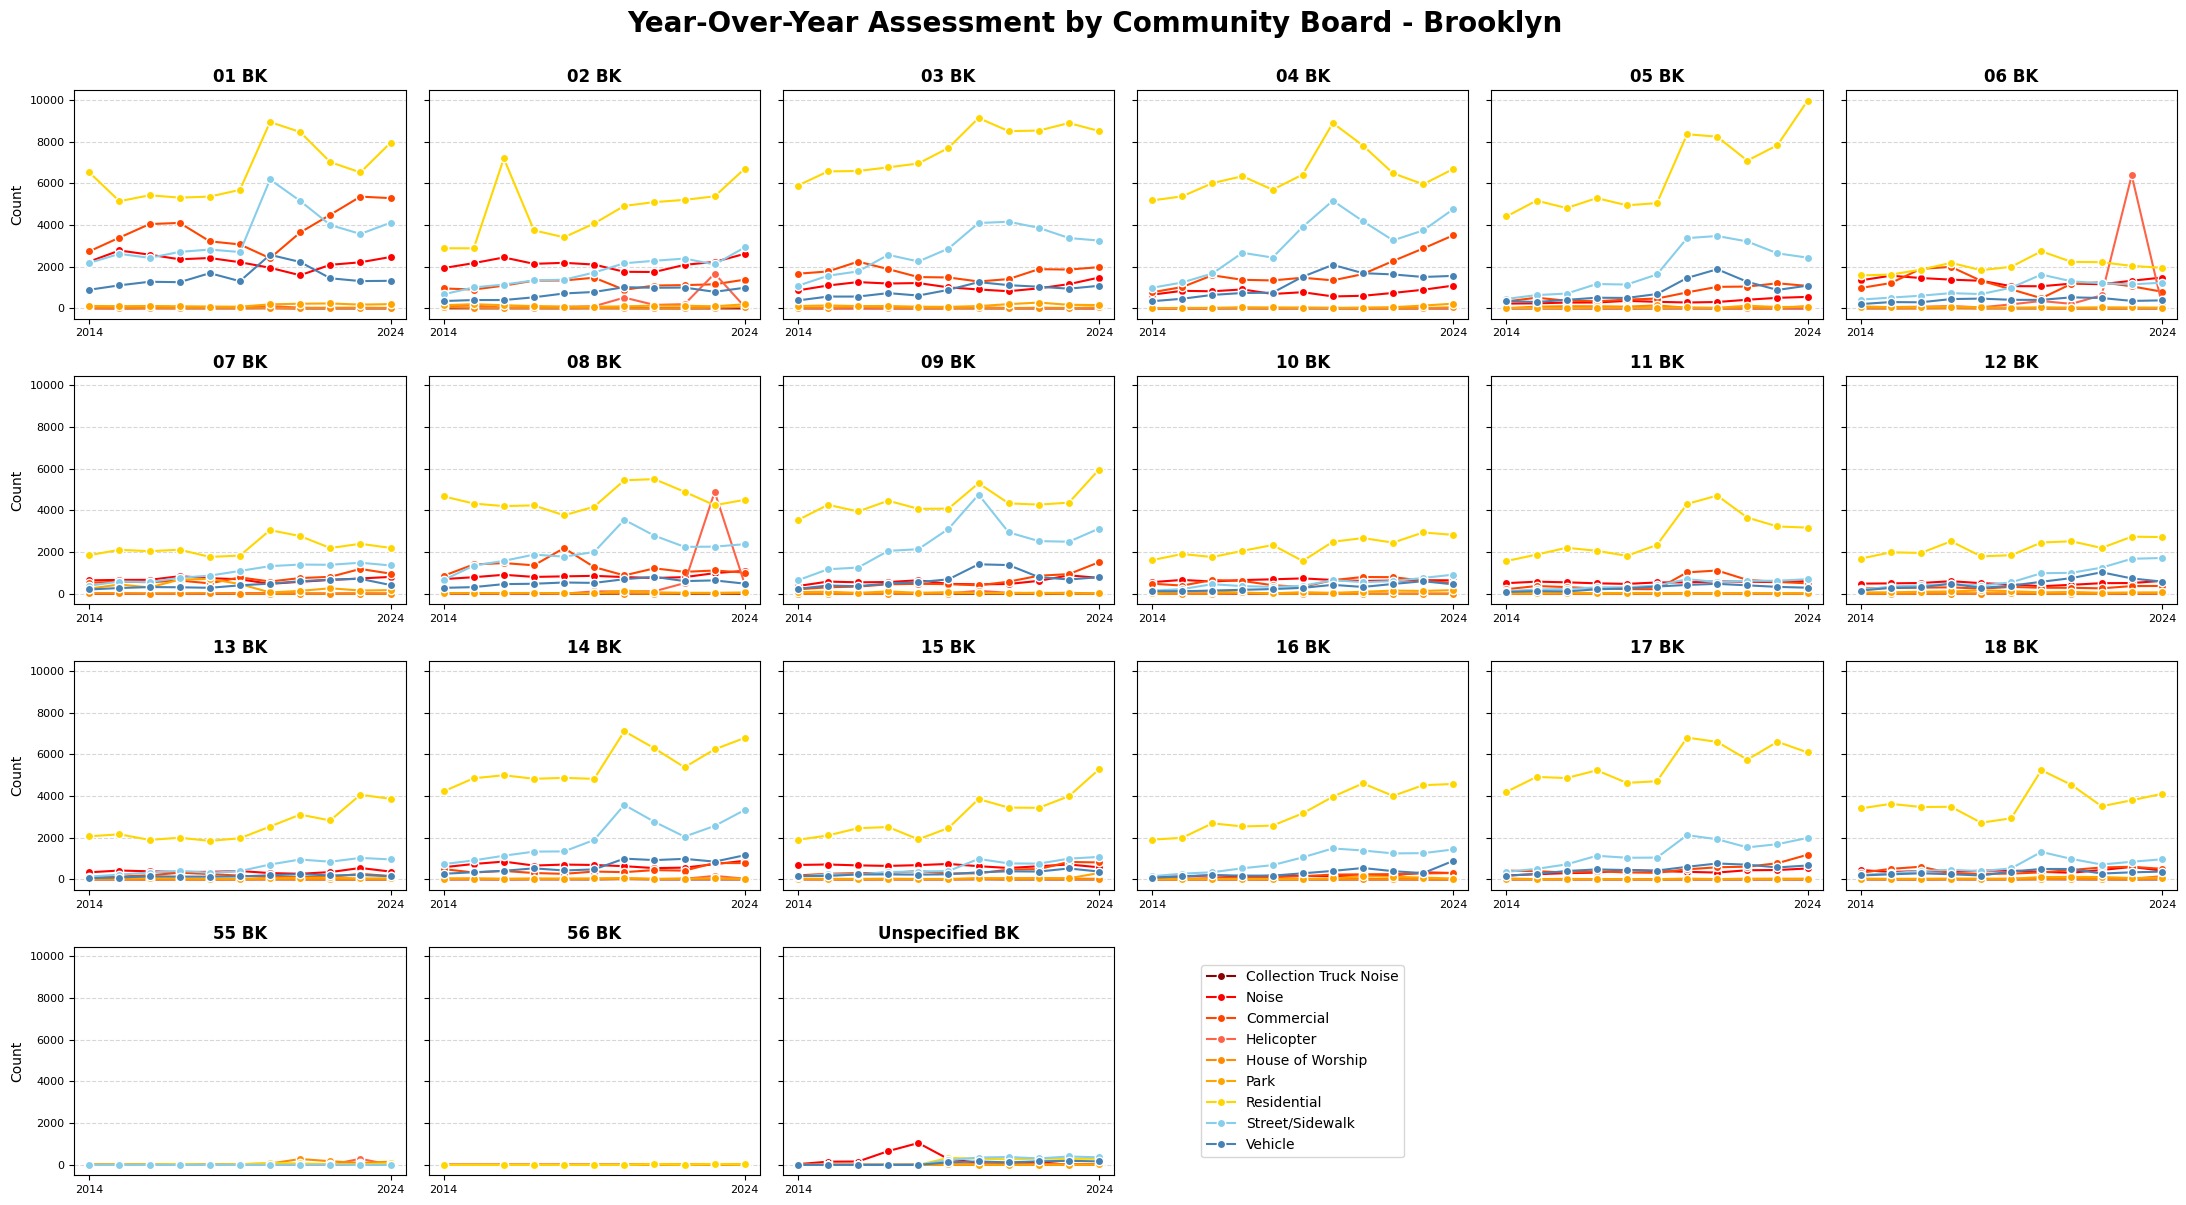

In [83]:
#filter for specific boro only
df_brooklyn = df_copy[df_copy['Borough'] == 'BROOKLYN']

#unique community boards in boro
community_boards = df_brooklyn['Community Board'].dropna().unique()
community_boards = sorted([board for board in community_boards if 'BROOKLYN' in str(board)])
num_boards = len(community_boards)

#find index of 'Unspecified' if exists
unspecified_idx = None
for idx, board in enumerate(community_boards):
    if 'Unspecified' in board:
        unspecified_idx = idx
        break

#subplot grid size (add 1 for legend subplot)
ncols = 6
nrows = int(np.ceil((num_boards + 1) / ncols))  # add 1 for legend
fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 3), sharey=True)
axes = axes.flatten()

#main title
fig.suptitle('Year-Over-Year Assessment by Community Board - Brooklyn',
             fontsize=20, fontweight='bold', y=1.00)

#determine legend position: right after 'Unspecified' or at end if none
legend_pos = (unspecified_idx + 1) if unspecified_idx is not None else num_boards
ax_legend = axes[legend_pos]
ax_legend.axis('off')

#dummy plot for legend (use first board as sample)
df_board_sample = df_brooklyn[df_brooklyn['Community Board'] == community_boards[0]]
complaint_yearly_sample = df_board_sample.groupby(['Created_Year', 'Complaint Type']).size().unstack(fill_value=0)

for j, complaint in enumerate(complaint_yearly_sample.columns):
    color = neon_colors[j % len(neon_colors)]
    clean_label = complaint.replace('Noise - ', '')
    ax_legend.plot([], [], marker='o', label=clean_label, color=color, markeredgecolor='white')

ax_legend.legend(fontsize=10, title='', loc='center', frameon=True)

#plot each community board
for i, board in enumerate(community_boards):
    #skip legend subplot
    ax_idx = i if legend_pos > i else i + 1
    ax = axes[ax_idx]

    df_board = df_brooklyn[df_brooklyn['Community Board'] == board]
    complaint_yearly = df_board.groupby(['Created_Year', 'Complaint Type']).size().unstack(fill_value=0)

    for j, complaint in enumerate(complaint_yearly.columns):
        color = neon_colors[j % len(neon_colors)]
        clean_label = complaint.replace('Noise - ', '')
        ax.plot(complaint_yearly.index, complaint_yearly[complaint],
                marker='o', color=color, markeredgecolor='white')

    board_title = board.replace('BROOKLYN', 'BK')
    ax.set_title(f'{board_title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count' if ax_idx % ncols == 0 else '')
    years = complaint_yearly.index
    ax.set_xticks([years[0], years[-1]])
    ax.tick_params(axis='both', labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

#remove unused axes
for j in range(num_boards + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Queens

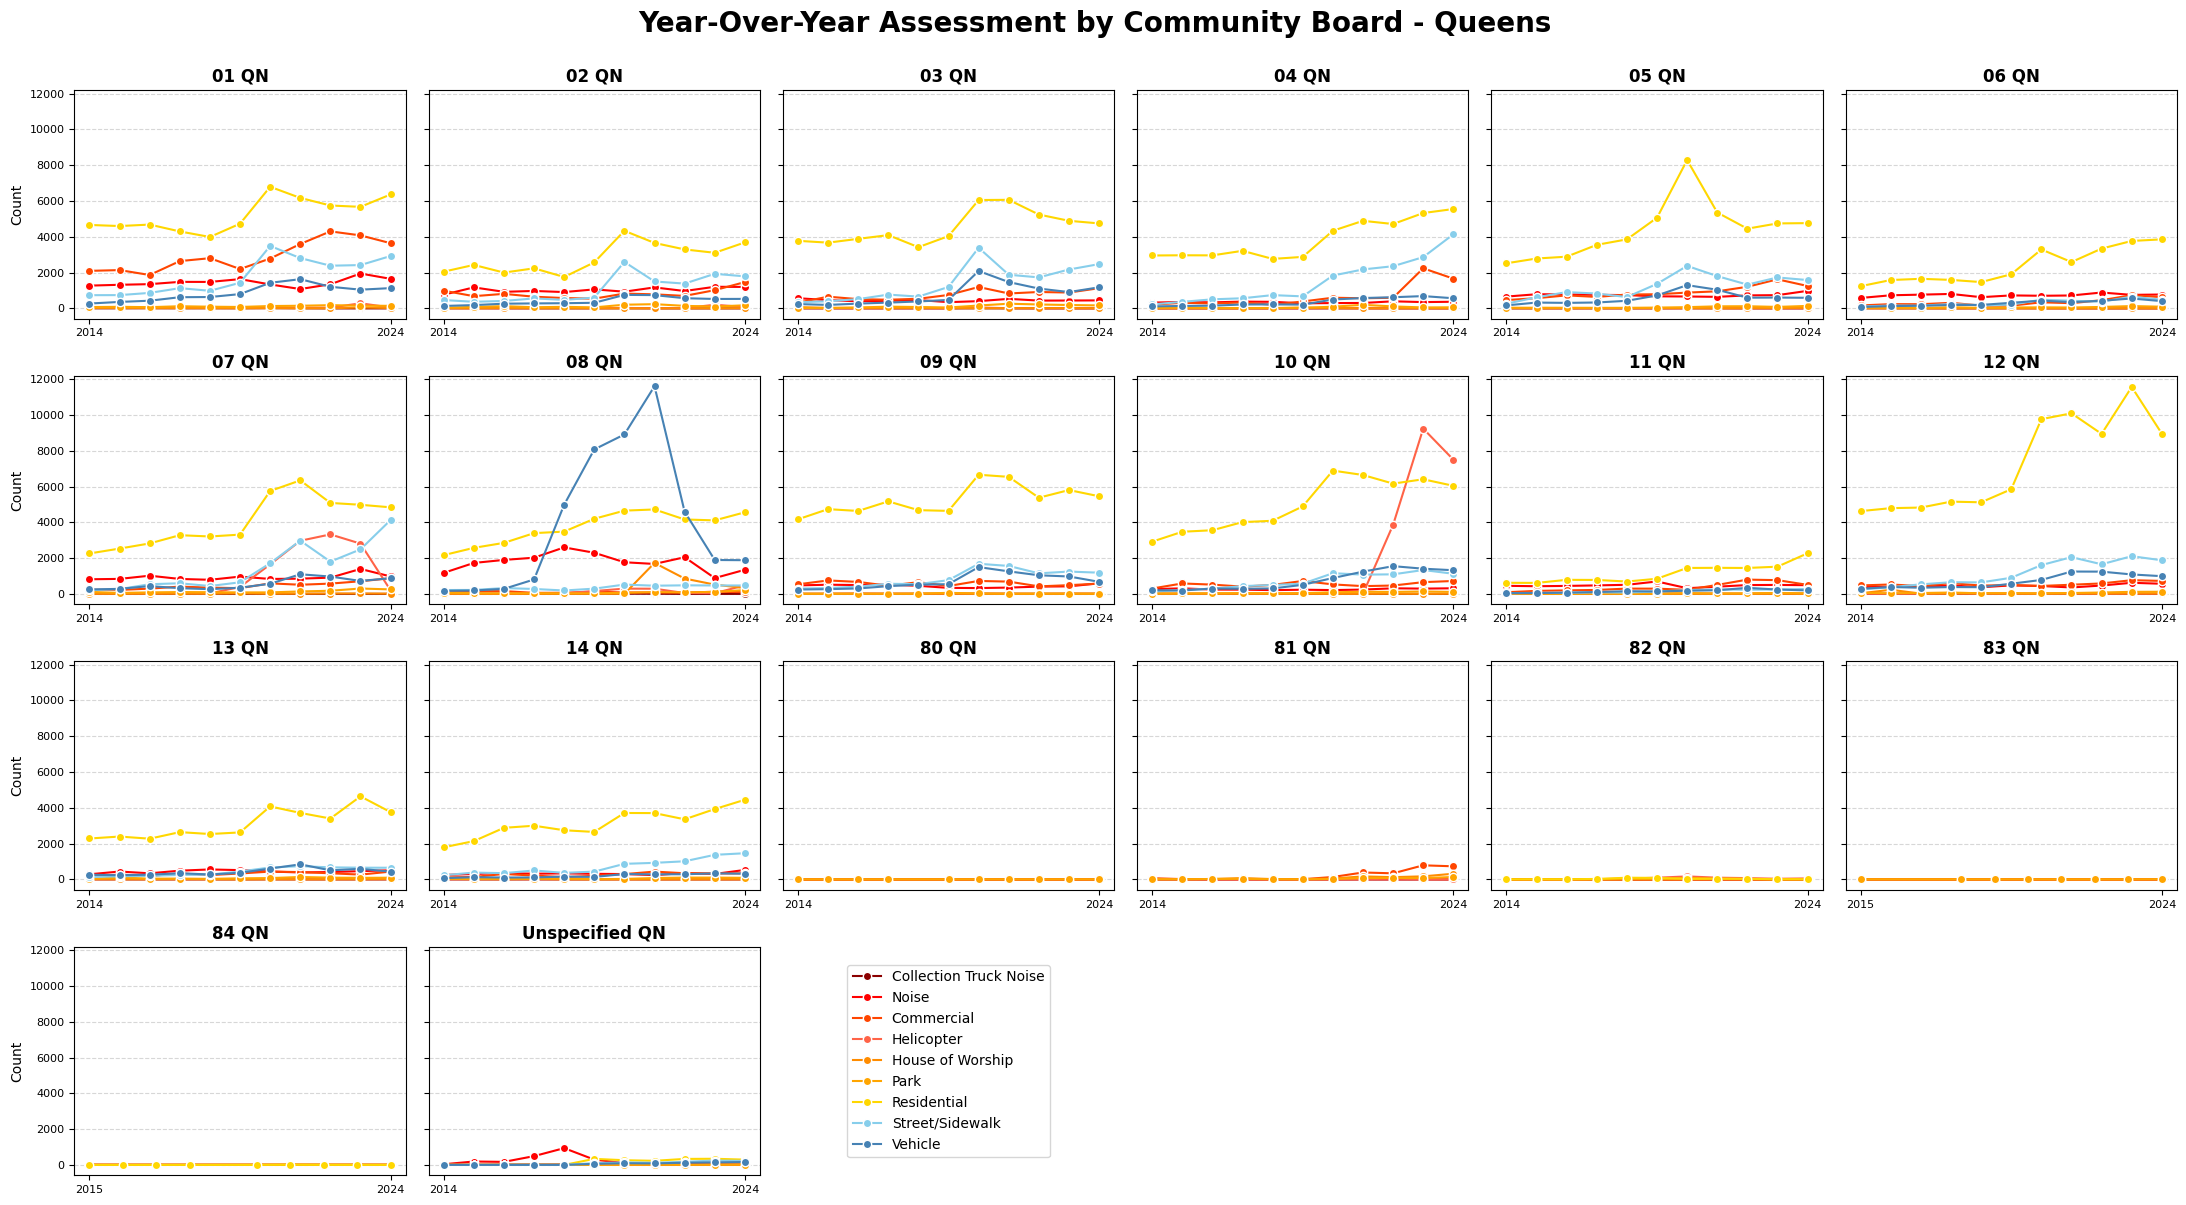

In [84]:
#filter for specific boro only
df_queens = df_copy[df_copy['Borough'] == 'QUEENS']

#unique community boards in boro
community_boards = df_queens['Community Board'].dropna().unique()
community_boards = sorted([board for board in community_boards if 'QUEENS' in str(board)])
num_boards = len(community_boards)

#find index of 'Unspecified' if exists
unspecified_idx = None
for idx, board in enumerate(community_boards):
    if 'Unspecified' in board:
        unspecified_idx = idx
        break

#subplot grid size (add 1 for legend subplot)
ncols = 6
nrows = int(np.ceil((num_boards + 1) / ncols))  # add 1 for legend
fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 3), sharey=True)
axes = axes.flatten()

#main title
fig.suptitle('Year-Over-Year Assessment by Community Board - Queens',
             fontsize=20, fontweight='bold', y=1.00)

#determine legend position: right after 'Unspecified' or at end if none
legend_pos = (unspecified_idx + 1) if unspecified_idx is not None else num_boards
ax_legend = axes[legend_pos]
ax_legend.axis('off')

#dummy plot for legend (use first board as sample)
df_board_sample = df_queens[df_queens['Community Board'] == community_boards[0]]
complaint_yearly_sample = df_board_sample.groupby(['Created_Year', 'Complaint Type']).size().unstack(fill_value=0)

for j, complaint in enumerate(complaint_yearly_sample.columns):
    color = neon_colors[j % len(neon_colors)]
    clean_label = complaint.replace('Noise - ', '')
    ax_legend.plot([], [], marker='o', label=clean_label, color=color, markeredgecolor='white')

ax_legend.legend(fontsize=10, title='', loc='center', frameon=True)

#plot each community board
for i, board in enumerate(community_boards):
    #skip legend subplot
    ax_idx = i if legend_pos > i else i + 1
    ax = axes[ax_idx]

    df_board = df_queens[df_queens['Community Board'] == board]
    complaint_yearly = df_board.groupby(['Created_Year', 'Complaint Type']).size().unstack(fill_value=0)

    for j, complaint in enumerate(complaint_yearly.columns):
        color = neon_colors[j % len(neon_colors)]
        clean_label = complaint.replace('Noise - ', '')
        ax.plot(complaint_yearly.index, complaint_yearly[complaint],
                marker='o', color=color, markeredgecolor='white')

    board_title = board.replace('QUEENS', 'QN')
    ax.set_title(f'{board_title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count' if ax_idx % ncols == 0 else '')
    years = complaint_yearly.index
    ax.set_xticks([years[0], years[-1]])
    ax.tick_params(axis='both', labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

#remove unused axes
for j in range(num_boards + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Staten Island

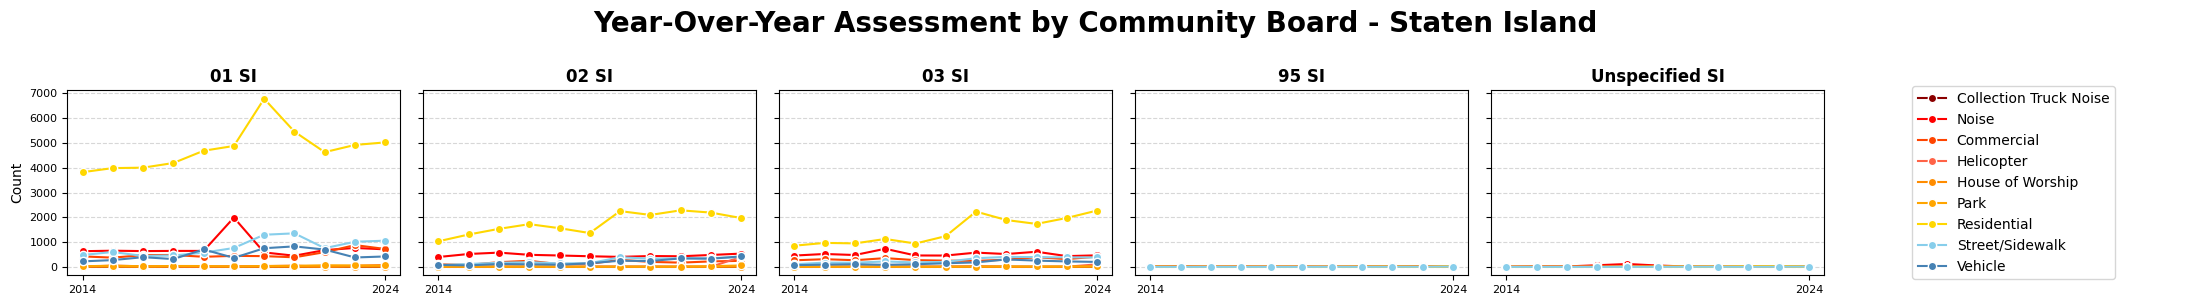

In [85]:
#filter for specific boro only
df_staten = df_copy[df_copy['Borough'] == 'STATEN ISLAND']

#unique community boards in boro
community_boards = df_staten['Community Board'].dropna().unique()
community_boards = sorted([board for board in community_boards if 'STATEN ISLAND' in str(board)])
num_boards = len(community_boards)

#find index of 'Unspecified' if exists
unspecified_idx = None
for idx, board in enumerate(community_boards):
    if 'Unspecified' in board:
        unspecified_idx = idx
        break

#subplot grid size (add 1 for legend subplot)
ncols = 6
nrows = int(np.ceil((num_boards + 1) / ncols))  # add 1 for legend
fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 3), sharey=True)
axes = axes.flatten()

#main title
fig.suptitle('Year-Over-Year Assessment by Community Board - Staten Island',
             fontsize=20, fontweight='bold', y=1.00)

#determine legend position: right after 'Unspecified' or at end if none
legend_pos = (unspecified_idx + 1) if unspecified_idx is not None else num_boards
ax_legend = axes[legend_pos]
ax_legend.axis('off')

#dummy plot for legend (use first board as sample)
df_board_sample = df_staten[df_staten['Community Board'] == community_boards[0]]
complaint_yearly_sample = df_board_sample.groupby(['Created_Year', 'Complaint Type']).size().unstack(fill_value=0)

for j, complaint in enumerate(complaint_yearly_sample.columns):
    color = neon_colors[j % len(neon_colors)]
    clean_label = complaint.replace('Noise - ', '')
    ax_legend.plot([], [], marker='o', label=clean_label, color=color, markeredgecolor='white')

ax_legend.legend(fontsize=10, title='', loc='center', frameon=True)

#plot each community board
for i, board in enumerate(community_boards):
    #skip legend subplot
    ax_idx = i if legend_pos > i else i + 1
    ax = axes[ax_idx]

    df_board = df_staten[df_staten['Community Board'] == board]
    complaint_yearly = df_board.groupby(['Created_Year', 'Complaint Type']).size().unstack(fill_value=0)

    for j, complaint in enumerate(complaint_yearly.columns):
        color = neon_colors[j % len(neon_colors)]
        clean_label = complaint.replace('Noise - ', '')
        ax.plot(complaint_yearly.index, complaint_yearly[complaint],
                marker='o', color=color, markeredgecolor='white')

    board_title = board.replace('STATEN ISLAND', 'SI')
    ax.set_title(f'{board_title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count' if ax_idx % ncols == 0 else '')
    years = complaint_yearly.index
    ax.set_xticks([years[0], years[-1]])
    ax.tick_params(axis='both', labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

#remove unused axes
for j in range(num_boards + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## END

## NOT IMPLEMENTED -- VARIABLE CORRELATIONS
## NOT IMPLEMENTED -- SIGNIF OF FACTORS